# Technology Trends Analysis
IBM Data Analyst Capstone Project

## Project Overview

This project analyzes technology trends using developer survey data.

The analysis includes data cleaning, exploration, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading file

In [8]:
df = pd.read_csv("data/m5_survey_data_demographics.csv")
data = df.copy()
data.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


### Removing duplicates

In [9]:
duplicates = df[df.duplicated()].count()
duplicates

print('{} is Number of Duplicates'.format(duplicates))
duplicates = df[df.duplicated(subset=['Respondent'], keep = False)]
duplicates

Respondent      0
MainBranch      0
Hobbyist        0
OpenSourcer     0
OpenSource      0
               ..
Sexuality       0
Ethnicity       0
Dependents      0
SurveyLength    0
SurveyEase      0
Length: 70, dtype: int64 is Number of Duplicates


,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase


In [10]:
data.drop_duplicates(inplace = True)
data

print("{} is remaining non-duplicated count".format(data))

       Respondent                      MainBranch Hobbyist  \
0               4  I am a developer by profession       No   
1               9  I am a developer by profession      Yes   
2              13  I am a developer by profession      Yes   
3              16  I am a developer by profession      Yes   
4              17  I am a developer by profession      Yes   
...           ...                             ...      ...   
11393       25136  I am a developer by profession      Yes   
11394       25137  I am a developer by profession      Yes   
11395       25138  I am a developer by profession      Yes   
11396       25141  I am a developer by profession      Yes   
11397       25142  I am a developer by profession      Yes   

                                             OpenSourcer  \
0                                                  Never   
1                             Once a month or more often   
2      Less than once a month but more than once per ...   
3              

In [11]:
print("Number of Rows before Removing Duplicates: " + str(len(df)))
print("Number of Rows after Removing Duplicates: " + str(len(data)))

Number of Rows before Removing Duplicates: 11398
Number of Rows after Removing Duplicates: 11398


### Finding missing values

In [12]:
data.isnull()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11394,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11395,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11396,False,False,False,False,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [13]:
miss_workloc = data['WorkLoc'].isnull().sum()
print("Missing Values in WorkLoc Column is: " + str(miss_workloc))

Missing Values in WorkLoc Column is: 32


### Imputing missing values

In [14]:
count_workloc = data['WorkLoc'].value_counts()
count_workloc

WorkLoc
Office                                            6806
Home                                              3589
Other place, such as a coworking space or cafe     971
Name: count, dtype: int64

In [15]:
majority_val = max(count_workloc)
print("The max frequency of a word occurance in WorkLoc is " + str(count_workloc))

The max frequency of a word occurance in WorkLoc is WorkLoc
Office                                            6806
Home                                              3589
Other place, such as a coworking space or cafe     971
Name: count, dtype: int64


In [16]:
data['WorkLoc'] = data['WorkLoc'].fillna(data['WorkLoc'].mode().iloc[0])

In [17]:
data['WorkLoc'].isnull().sum()

0

### Normalizing data

In [19]:
comp_freq = data['CompFreq'].value_counts() #various categories in the column 'CompFreq'
comp_freq

CompFreq
Yearly     6073
Monthly    4788
Weekly      331
Name: count, dtype: int64

In [20]:
# a new column named 'NormalizedAnnualCompensation'
def norm_comp(CompFreq, CompTotal):
    i = 0
    if CompFreq == 'Monthly':
        i = CompTotal * 12
    elif CompFreq == 'Weekly':
        i = CompTotal * 52
    else:
        i = CompTotal
    return i
data['NormalizedAnnualCompensation'] = data.apply(lambda x: norm_comp(x['CompFreq'], x['CompTotal']), axis = 1)
data['NormalizedAnnualCompensation']

0         61000.0
1        138000.0
2         90000.0
3        348000.0
4         90000.0
           ...   
11393    130000.0
11394     74400.0
11395    105000.0
11396     80000.0
11397         NaN
Name: NormalizedAnnualCompensation, Length: 11398, dtype: float64

### Statistics and visualization

C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\1027608382.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['ConvertedComp'], kde=True, bins=bins)


Text(0, 0.5, 'Freq. Count')

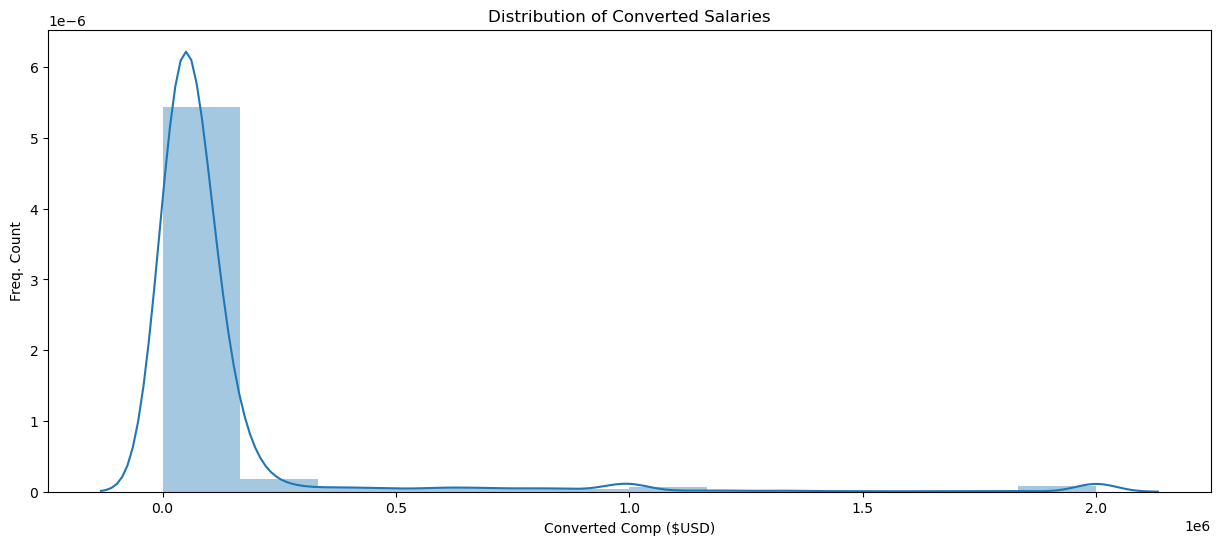

In [23]:
median = data['ConvertedComp'].median()
data['ConvertedComp'] = data['ConvertedComp'].fillna(median)

from statsmodels.formula.api import ols
import io
import requests


bins = np.linspace(min(data['ConvertedComp']), max(data['ConvertedComp']), 13)
plt.figure(figsize=(15, 6), edgecolor='blue')
sns.distplot(data['ConvertedComp'], kde=True, bins=bins)

plt.title('Distribution of Converted Salaries')
plt.xlabel('Converted Comp ($USD)')
plt.ylabel('Freq. Count')

Text(0, 0.5, 'Freq. Count')

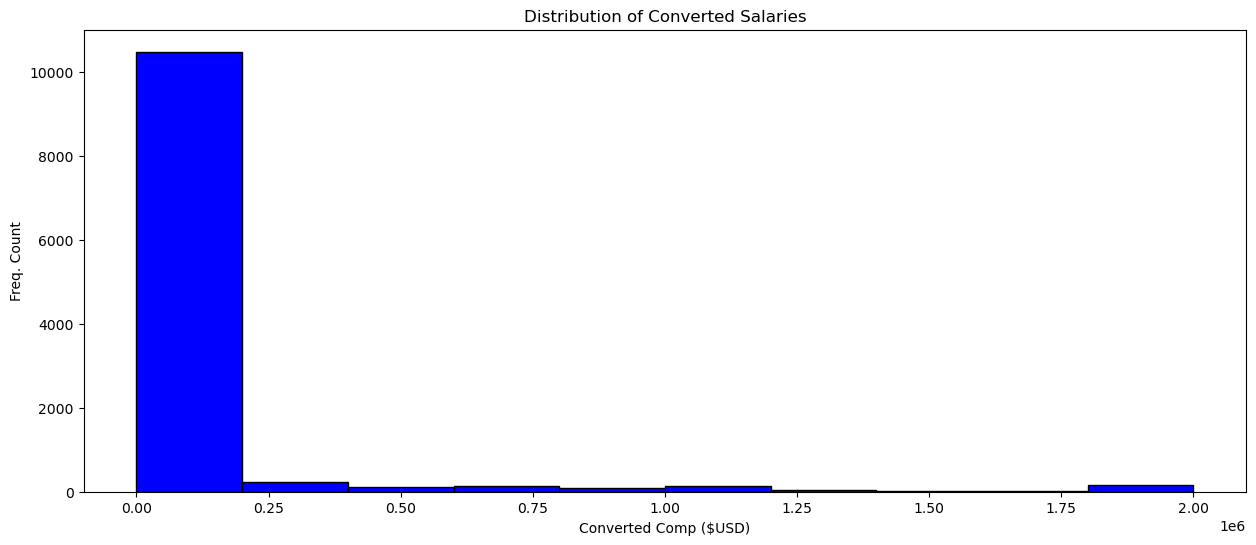

In [24]:
import matplotlib.pyplot as plt

bins = np.linspace(min(data['ConvertedComp']), max(data['ConvertedComp']), 13)
plt.figure(figsize=(15, 6),edgecolor='blue')
plt.hist(data['ConvertedComp'], color = 'blue', edgecolor = 'black', bins = int(2000000/200000))

plt.title('Distribution of Converted Salaries')
plt.xlabel('Converted Comp ($USD)')
plt.ylabel('Freq. Count')

In [29]:
data['ConvertedComp'].dtypes

dtype('float64')

In [28]:
data.dtypes

Respondent                        int64
MainBranch                       object
Hobbyist                         object
OpenSourcer                      object
OpenSource                       object
                                 ...   
Ethnicity                        object
Dependents                       object
SurveyLength                     object
SurveyEase                       object
NormalizedAnnualCompensation    float64
Length: 71, dtype: object

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11398 entries, 0 to 11397
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Respondent                    11398 non-null  int64  
 1   MainBranch                    11398 non-null  object 
 2   Hobbyist                      11398 non-null  object 
 3   OpenSourcer                   11398 non-null  object 
 4   OpenSource                    11317 non-null  object 
 5   Employment                    11398 non-null  object 
 6   Country                       11398 non-null  object 
 7   Student                       11347 non-null  object 
 8   EdLevel                       11286 non-null  object 
 9   UndergradMajor                10661 non-null  object 
 10  EduOther                      11234 non-null  object 
 11  OrgSize                       11302 non-null  object 
 12  DevType                       11333 non-null  object 
 13  Y

Text(0.5, 0, 'Salaries ($USD)')

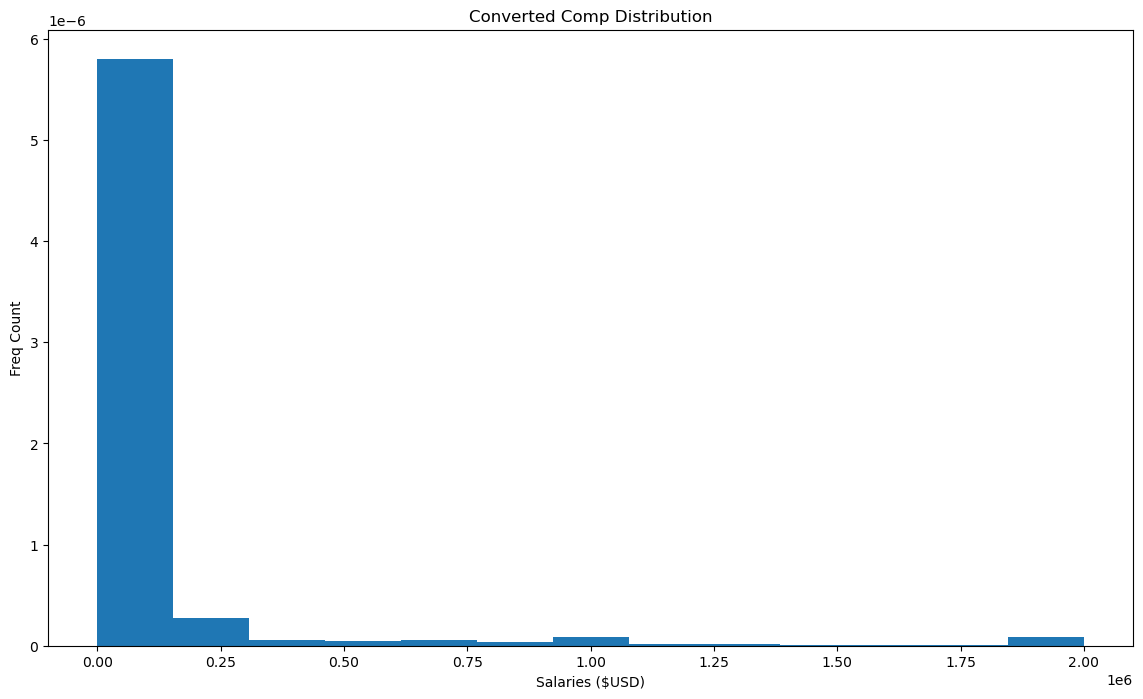

In [31]:
plt.figure(figsize=(14, 8), edgecolor='blue')
plt.hist(data['ConvertedComp'], density=True, bins=13)
plt.title('Converted Comp Distribution')
plt.ylabel('Freq Count')
plt.xlabel('Salaries ($USD)')

In [32]:
print('Median of the column ConvertedComp is {}'.format(df['ConvertedComp'].median()))

Median of the column ConvertedComp is 57745.0


In [33]:
data.describe()

,Respondent,CompTotal,ConvertedComp,WorkWeekHrs,CodeRevHrs,Age,NormalizedAnnualCompensation
count,11398.000000,1.058900e+04,1.139800e+04,11276.000000,8972.000000,11111.000000,1.058900e+04
mean,12490.392437,7.570477e+05,1.263096e+05,42.064606,4.781071,30.779138,6.133295e+06
std,7235.461999,9.705598e+06,2.846750e+05,24.672741,4.567060,7.393784,9.838157e+07
min,4.000000,0.000000e+00,0.000000e+00,3.000000,0.000000,16.000000,0.000000e+00
25%,6264.250000,2.500000e+04,2.901600e+04,40.000000,2.000000,25.000000,5.200000e+04
50%,12484.000000,6.500000e+04,5.774500e+04,40.000000,4.000000,29.000000,1.000000e+05
75%,18784.750000,1.200000e+05,9.500000e+04,43.000000,5.000000,35.000000,3.600000e+05
max,25142.000000,7.000000e+08,2.000000e+06,1012.000000,99.000000,99.000000,8.400000e+09


In [34]:
#assessing NAN in numeric fields

#see if any missing values:
if data['WorkWeekHrs'].isnull().sum():
    mean_work = data['WorkWeekHrs'].mean()
    data['WorkWeekHrs'].replace(np.nan, mean_work, inplace=True)
    
if data['Age'].isnull().sum():
    mean_age = data['Age'].mean()
    data['Age'].replace(np.nan, mean_age, inplace=True)
    
if data['CompTotal'].isnull().sum():
    mean_comp_total = data['CompTotal'].mean()
    data['CompTotal'].replace(np.nan, mean_comp_total, inplace=True)
    
if data['ConvertedComp'].isnull().sum():
    mean_conv_comp = data['ConvertedComp'].mean()
    data['ConvertedComp'].replace(np.nan, mean_conv_comp, inplace=True)
    
if data['CodeRevHrs'].isnull().sum():
    mean_code = data['CodeRevHrs'].mean()
    data['CodeRevHrs'].replace(np.nan, mean_code, inplace=True)

C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\542221653.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['WorkWeekHrs'].replace(np.nan, mean_work, inplace=True)
C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\542221653.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

In [37]:
#  replacing nan values in Age column with mean age

mean_age = data['Age'].mean()
data['Age'] = data['Age'].fillna(mean_age)

In [38]:
data['Age'].isna().sum()

0

In [39]:
# five number summary for the column Age
data['Age'].describe()

from numpy import percentile

quartiles = percentile(data['Age'], [25, 50, 75])

Age_min, Age_max = data['Age'].min(), data['Age'].max()

print('Min: %.3f' % Age_min)
print('Q1: %.3f' % quartiles[0])
print('Median: %.3f' % quartiles[1])
print('Q3: %.3f' % quartiles[2])
print('Max: %.3f' % Age_max)

Min: 16.000
Q1: 26.000
Median: 29.000
Q3: 34.000
Max: 99.000


Text(0.5, 0, 'Age')

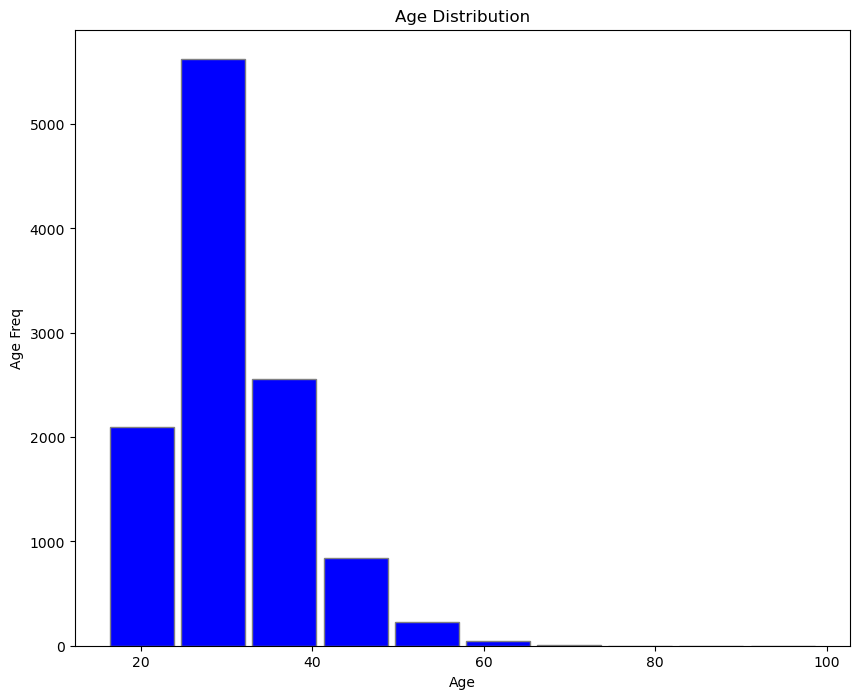

In [43]:
# plotting a histogram of the column Age

bin_width=8
bins = round((data['Age'].max() - data['Age'].min()) / bin_width)
hist_age = data.hist(column='Age', bins=bins, grid=False, figsize=(10,8), color='blue', edgecolor='grey', zorder=2, rwidth=0.9)
plt.title('Age Distribution')
plt.ylabel('Age Freq')
plt.xlabel('Age')

In [44]:
# number of responders identified themselves only as a Man

man_identity = data['Gender'].value_counts()[0]
man_identity

print('Number of Only Man/Male Responders is {}'.format(man_identity))

Number of Only Man/Male Responders is 10480


C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\2603139542.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  man_identity = data['Gender'].value_counts()[0]


In [45]:
# median ConvertedComp of responders identified themselves only as a Woman

woman_identity = data[['ConvertedComp', 'Gender']].groupby(['Gender'], as_index=False).median()
woman_identity

,Gender,ConvertedComp
0,Man,57745.0
1,"Man;Non-binary, genderqueer, or gender non-con...",59520.0
2,"Non-binary, genderqueer, or gender non-conforming",66000.0
3,Woman,57745.0
4,Woman;Man,25887.0
5,"Woman;Man;Non-binary, genderqueer, or gender n...",30244.0
6,"Woman;Non-binary, genderqueer, or gender non-c...",65535.5


In [46]:
woman_identity[woman_identity['Gender']=='Woman']

,Gender,ConvertedComp
3,Woman,57745.0


### Outliers

Text(0.5, 0, 'ConvertedComp ($USD)')

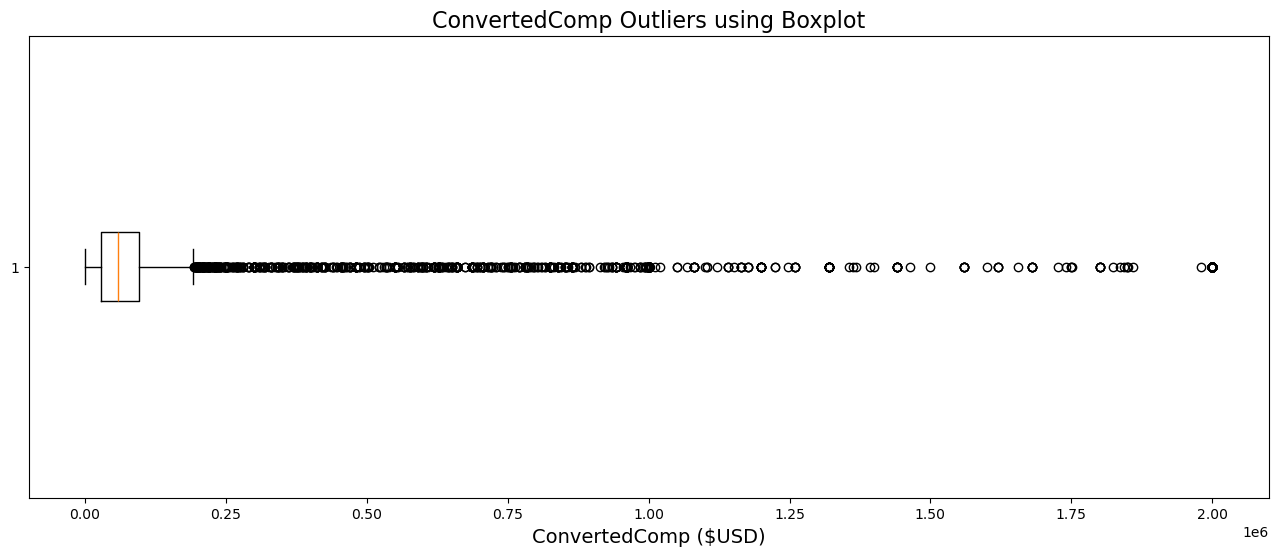

In [48]:
# outliers in the column ConvertedComp

plt.figure(figsize = (16, 6))
plt.boxplot(x=data['ConvertedComp'], vert=False)
plt.title('ConvertedComp Outliers using Boxplot', size=16)
plt.xlabel('ConvertedComp ($USD)', size=14)

In [49]:
# Inter Quartile Range for the column ConvertedComp

q3, q1 = np.percentile(data['ConvertedComp'], [75 ,25])
IQR = q3 - q1

print('Inter Quartile Range for ConvertedComp column is {}'.format(IQR))

Inter Quartile Range for ConvertedComp column is 65984.0


In [50]:
# upper and lower bounds

upper_bound = print('Upper bound is {}'.format(q3 + 1.5*IQR))
upper_bound

low_bound = print('Lower bound is {}'.format(q1 - 1.5*IQR))
low_bound

Upper bound is 193976.0
Lower bound is -69960.0


In [51]:
# number of outliers in the ConvertedComp column

lower_outliers = (data['ConvertedComp'] <= (q1 - 1.5 * IQR)).sum()
print('Number of outliers below Q1 is {}'.format(lower_outliers))

upper_outliers = (data['ConvertedComp'] >= (q3 + 1.5 * IQR)).sum()
print('Number of outliers above Q3 is {}'.format(upper_outliers))

total_outliers = lower_outliers + upper_outliers
print('Total number of outliers is {}'.format(total_outliers))

Number of outliers below Q1 is 0
Number of outliers above Q3 is 933
Total number of outliers is 933


In [52]:
# a new dataframe created by removing the outliers from the ConvertedComp column

upper = np.where(data['ConvertedComp'] >= (q3 + 1.5*IQR))
lower = np.where(data['ConvertedComp'] <= (q1 - 1.5*IQR))

mask = (data['ConvertedComp'] < (q1 - 1.5 * IQR)) | (data['ConvertedComp'] > (q3 + 1.5 * IQR))
data[mask] = np.nan
data['ConvertedComp'].mean()

dfNew = data.copy()

In [53]:
dfNew.shape

(11398, 71)

In [54]:
dfNew['ConvertedComp']

0         61000.0
1         95179.0
2         90000.0
3             NaN
4         65277.0
           ...   
11393    130000.0
11394     19880.0
11395    105000.0
11396     80371.0
11397     57745.0
Name: ConvertedComp, Length: 11398, dtype: float64

In [55]:
if dfNew['WorkWeekHrs'].isnull().sum():
    mean_work = dfNew['WorkWeekHrs'].mean()
    dfNew['WorkWeekHrs'].replace(np.nan, mean_work, inplace=True)
    
if dfNew['Age'].isnull().sum():
    mean_age = dfNew['Age'].mean()
    dfNew['Age'].replace(np.nan, mean_age, inplace=True)
    
if dfNew['CompTotal'].isnull().sum():
    mean_comp_total = dfNew['CompTotal'].mean()
    dfNew['CompTotal'].replace(np.nan, mean_comp_total, inplace=True)
    
if dfNew['ConvertedComp'].isnull().sum():
    mean_conv_comp = dfNew['ConvertedComp'].mean()
    dfNew['ConvertedComp'].replace(np.nan, mean_conv_comp, inplace=True)
    
if dfNew['CodeRevHrs'].isnull().sum():
    mean_code = dfNew['CodeRevHrs'].mean()
    dfNew['CodeRevHrs'].replace(np.nan, mean_code, inplace=True)

C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\3155646512.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfNew['WorkWeekHrs'].replace(np.nan, mean_work, inplace=True)
C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\3155646512.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [56]:
print('ConvertedComp mean after dropping otliers {}'.format(dfNew['ConvertedComp'].mean(),2))

ConvertedComp mean after dropping otliers 58992.50339225992


In [57]:
dfNew.describe()

,Respondent,CompTotal,ConvertedComp,WorkWeekHrs,CodeRevHrs,Age,NormalizedAnnualCompensation
count,10465.000000,1.139800e+04,11398.000000,11398.000000,11398.000000,11398.000000,9.656000e+03
mean,12494.160057,7.297042e+05,58992.503392,41.876188,4.802223,30.625729,5.492211e+06
std,7234.905154,6.630982e+06,38849.606048,23.208439,3.945248,6.941394,5.667468e+07
min,4.000000,0.000000e+00,0.000000,3.000000,0.000000,16.000000,0.000000e+00
25%,6261.000000,3.000000e+04,29016.000000,40.000000,3.000000,26.000000,5.000000e+04
50%,12485.000000,7.900000e+04,57745.000000,40.000000,4.781071,30.000000,9.000000e+04
75%,18802.000000,1.923750e+05,78000.000000,42.000000,5.000000,33.000000,1.900000e+05
max,25142.000000,3.900000e+08,192500.000000,1012.000000,99.000000,99.000000,1.416000e+09


In [58]:
print('Median of ConvertedComp colunn is {}'.format(dfNew['ConvertedComp'].median()))

Median of ConvertedComp colunn is 57745.0


Text(0.5, 0, 'ConvertedComp ($USD)')

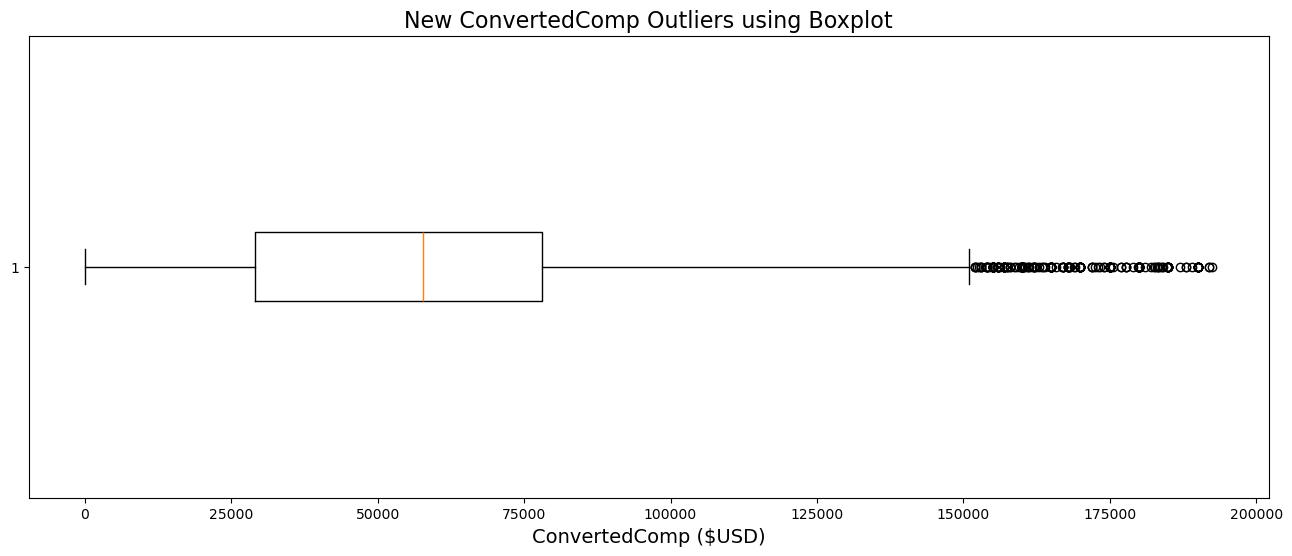

In [59]:
plt.figure(figsize = (16, 6))
plt.boxplot(x=dfNew['ConvertedComp'], vert=False)
plt.title('New ConvertedComp Outliers using Boxplot', size=16)
plt.xlabel('ConvertedComp ($USD)', size=14)

In [62]:
lower_outliers = (dfNew['ConvertedComp'] <= (q1 - 1.5 * IQR)).sum()
print('Number of outliers below Q1 is {}'.format(lower_outliers))
      
upper_outliers = (dfNew['ConvertedComp'] >= (q3 + 1.5 * IQR)).sum() 
print('Numberr of outliers above Q3 is {}'.format(upper_outliers))
      
total_outliers = lower_outliers + upper_outliers
print('Total outliers are {}'.format(total_outliers))

Number of outliers below Q1 is 0
Numberr of outliers above Q3 is 0
Total outliers are 0


### Data visualizaion

In [67]:
from pandas.api.types import is_numeric_dtype  
import sqlite3
conn = sqlite3.connect("data/m4_survey_data.sqlite")

In [68]:
# how many rows are there in the table named 'master'

QUERY = """
SELECT COUNT(*)
FROM master
"""

df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT(*)
0,11398


In [69]:
# printing the tables names

QUERY = """
SELECT name as Table_Name FROM
sqlite_master WHERE
type = 'table'
"""

pd.read_sql_query(QUERY, conn)

,Table_Name
0,EduOther
1,DevType
2,LastInt
3,JobFactors
4,WorkPlan
5,WorkChallenge
6,LanguageWorkedWith
7,LanguageDesireNextYear
8,DatabaseWorkedWith
9,DatabaseDesireNextYear


In [70]:
# running a group by query

QUERY = """
SELECT Age, COUNT(*) as count
FROM master
group by age
order by age
"""

pd.read_sql_query(QUERY, conn) 

,Age,count
0,NaN,287
1,16.0,3
2,17.0,6
3,18.0,29
4,19.0,78
5,20.0,109
6,21.0,203
7,22.0,406
8,23.0,581
9,24.0,679


### Visualizing distribution of data

In [72]:
# a histogram of ConvertedComp

df = pd.read_sql_query("SELECT * FROM master", conn)
df

,index,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,...,SOPartFreq,SOJobs,EntTeams,SOComm,WelcomeChange,Age,Trans,Dependents,SurveyLength,SurveyEase
0,0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)",...,Less than once per month or monthly,Yes,"No, and I don't know what those are","No, not really",Just as welcome now as I felt last year,22.0,No,No,Appropriate in length,Easy
1,1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,...,Less than once per month or monthly,"No, I knew that Stack Overflow had a job board...","No, and I don't know what those are","Yes, somewhat",Just as welcome now as I felt last year,23.0,No,No,Appropriate in length,Neither easy nor difficult
2,2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",...,Less than once per month or monthly,Yes,"No, I've heard of them, but I am not part of a...",Neutral,Somewhat more welcome now than last year,28.0,No,Yes,Appropriate in length,Easy
3,3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",...,Less than once per month or monthly,Yes,"No, I've heard of them, but I am not part of a...","Yes, somewhat",Just as welcome now as I felt last year,26.0,No,No,Appropriate in length,Neither easy nor difficult
4,4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)",...,A few times per week,"No, I didn't know that Stack Overflow had a jo...","No, I've heard of them, but I am not part of a...","Yes, somewhat",Just as welcome now as I felt last year,29.0,No,No,Appropriate in length,Easy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11393,11393,25136,I am a developer by profession,Yes,Never,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",...,None,"No, I knew that Stack Overflow had a job board...","No, I've heard of them, but I am not part of a...","Yes, somewhat",Just as welcome now as I felt last year,36.0,No,No,Appropriate in length,Difficult
11394,11394,25137,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,Poland,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",...,I have never participated in Q&A on Stack Over...,"No, I knew that Stack Overflow had a job board...","No, and I don't know what those are",Neutral,A lot more welcome now than last year,25.0,No,No,Appropriate in length,Neither easy nor difficult
11395,11395,25138,I am a developer by profession,Yes,Less than once per year,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",...,I have never participated in Q&A on Stack Over...,Yes,"No, I've heard of them, but I am not part of a...",Neutral,A lot more welcome now than last year,34.0,No,Yes,Too long,Easy
11396,11396,25141,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of LOWER quality than prop...",Employed full-time,Switzerland,No,"Secondary school (e.g. American high school, G...",...,Daily or almost daily,Yes,"No, I've heard of them, but I am not part of a...","Yes, somewhat",Somewhat less welcome now than last year,25.0,No,No,Appropriate in length,Easy


Text(0, 0.5, 'Freqency Count')

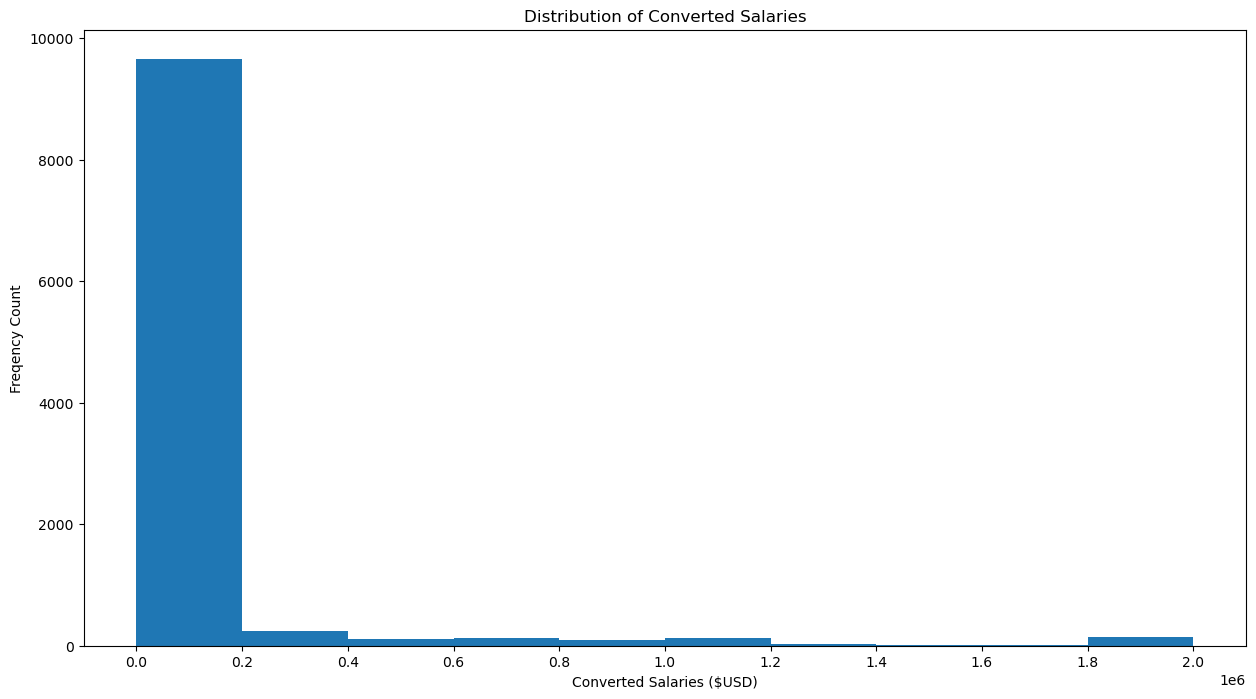

In [73]:
count, bin_edges = np.histogram(df['ConvertedComp'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
df["ConvertedComp"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Distribution of Converted Salaries")
plt.xlabel("Converted Salaries ($USD)")
plt.ylabel("Freqency Count")

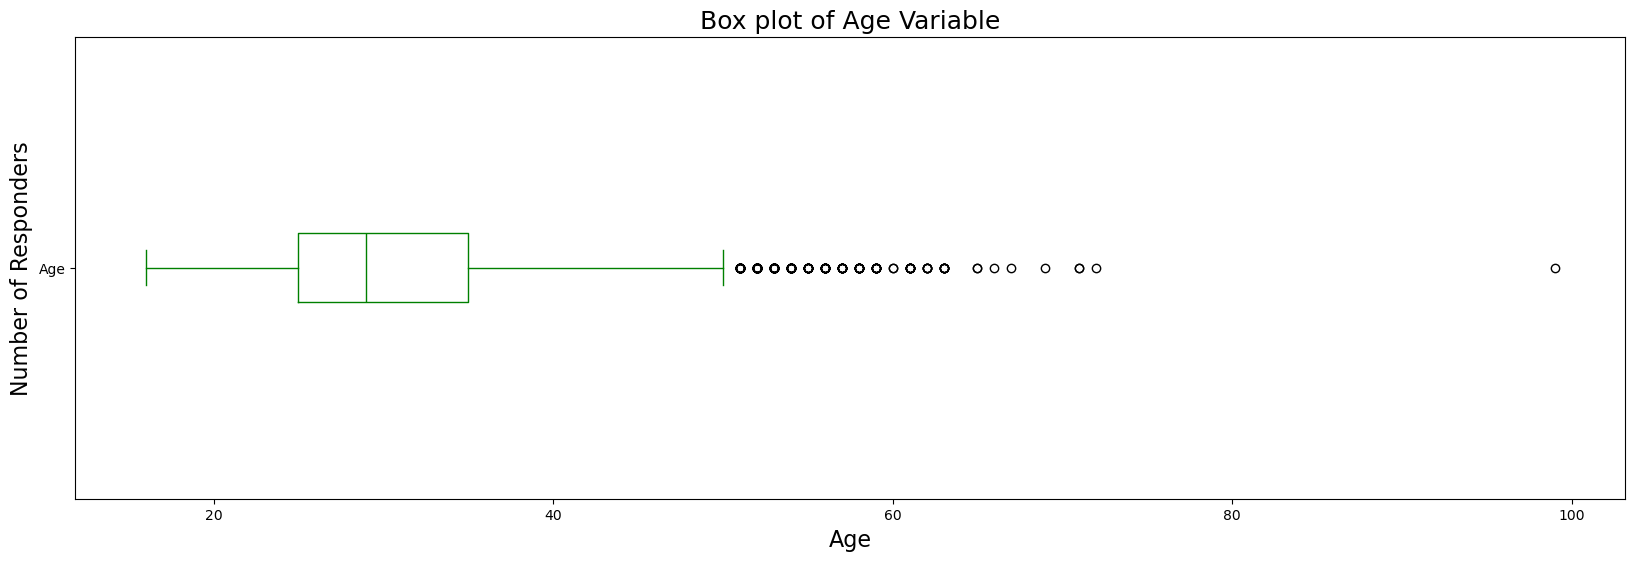

In [74]:
# a box plot of Age

df['Age'].plot(kind='box', vert=False, color='green', figsize=(20, 6))

plt.title('Box plot of Age Variable', size=18)
plt.xlabel('Age', size=16)
plt.ylabel('Number of Responders', size=16)

plt.show()

In [75]:
# a scatter plot of Age and WorkWeekHrs

QUERY = """
SELECT Age, WorkWeekHrs FROM master
"""

dfScattr = pd.read_sql_query(QUERY, conn)
dfScattr

,Age,WorkWeekHrs
0,22.0,80.0
1,23.0,32.0
2,28.0,40.0
3,26.0,40.0
4,29.0,45.0
...,...,...
11393,36.0,40.0
11394,25.0,40.0
11395,34.0,40.0
11396,25.0,42.5


In [76]:
if dfScattr['WorkWeekHrs'].isnull().sum(): 
    meanScattr = dfScattr['WorkWeekHrs'].mean()
    dfScattr['WorkWeekHrs'].replace(np.nan, meanScattr, inplace=True)
    
if dfScattr['Age'].isnull().sum():
    meanAge = dfScattr['Age'].mean()
    dfScattr['Age'].replace(np.nan, meanAge, inplace=True)

C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\467368905.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfScattr['WorkWeekHrs'].replace(np.nan, meanScattr, inplace=True)
C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\467368905.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

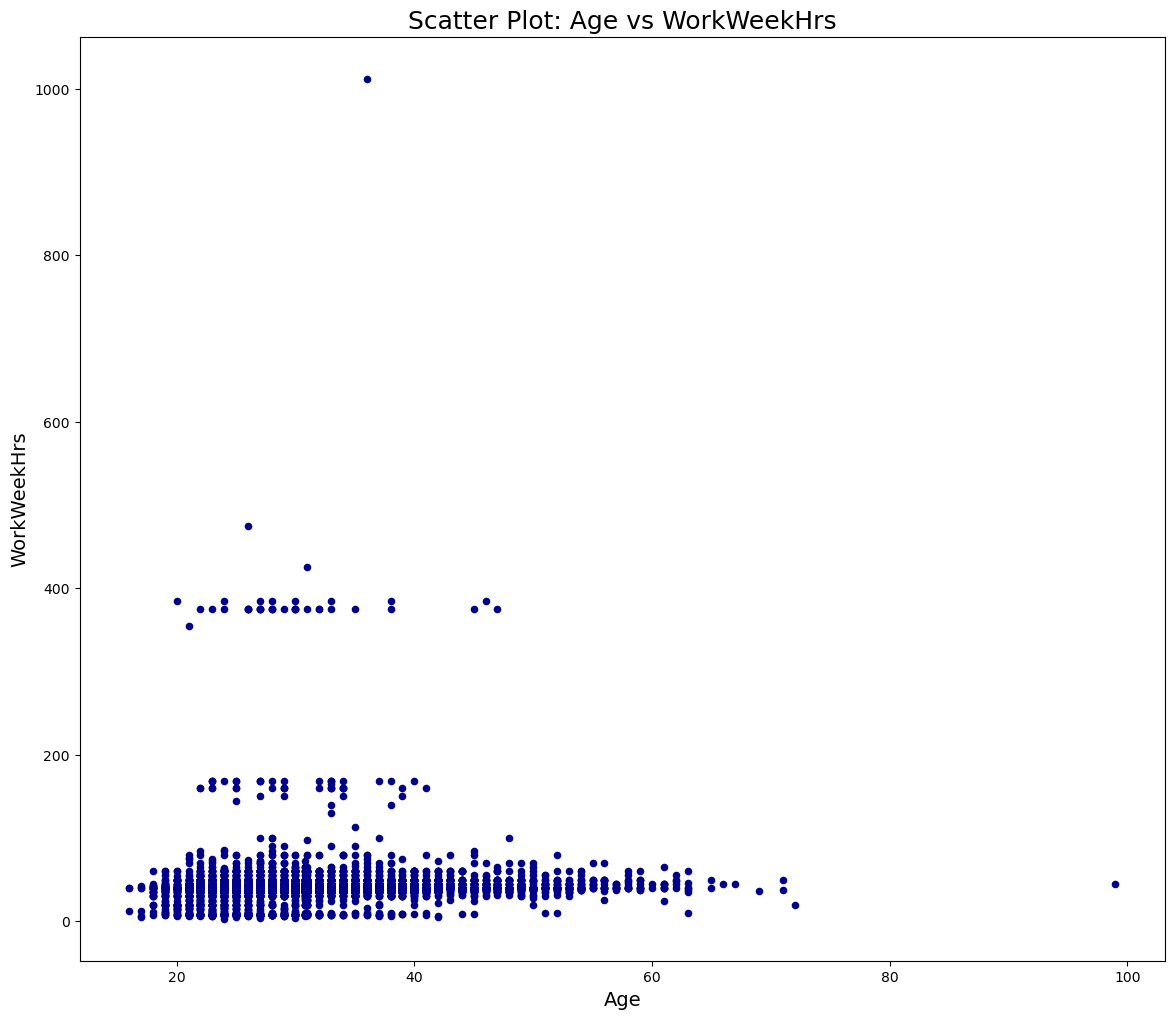

In [77]:
dfScattr.plot(kind='scatter', x='Age', y='WorkWeekHrs', figsize=(14, 12), color='darkblue')

plt.title('Scatter Plot: Age vs WorkWeekHrs', size=18)
plt.xlabel('Age', size=14)
plt.ylabel('WorkWeekHrs', size=14)
plt.show()

Text(0, 0.5, 'WorkWeekHrs')

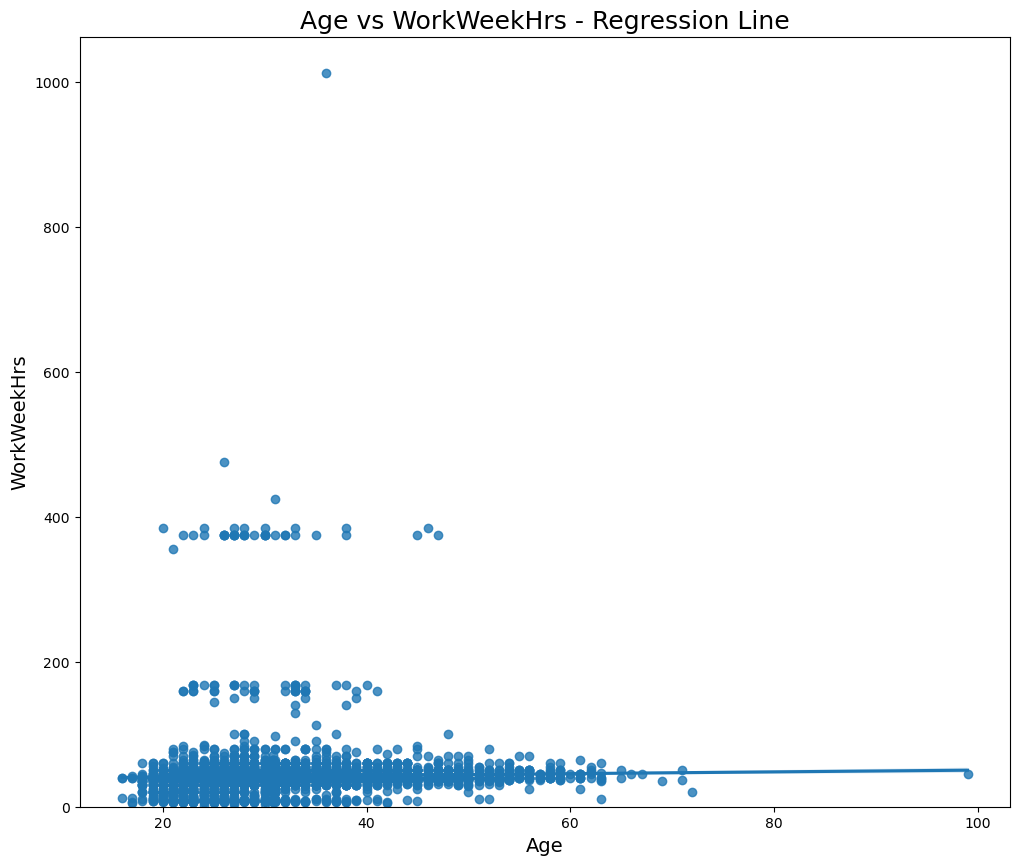

In [78]:
# using SNS to plot relationship between Age & WeekWorkHrs

plt.figure(figsize = (12, 10))
sns.regplot(x='Age', y='WorkWeekHrs', data=dfScattr)
plt.ylim(0, )
plt.title('Age vs WorkWeekHrs - Regression Line', size=18)
plt.xlabel('Age', size=14)
plt.ylabel('WorkWeekHrs', size=14)

In [79]:
# a bubble plot of WorkWeekHrs and CodeRevHrs using Age column as bubble size

dfBubble = pd.read_sql_query("SELECT WorkWeekHrs, CodeRevHrs, Age FROM master" , conn)

In [80]:
# a function to replace NANs for numeric and non-numerical columns

from pandas.api.types import is_numeric_dtype  

def ReplMissVal(x):
    
    import numpy as np
    import pandas as pd
    
    if is_numeric_dtype(x):
        replcemnt = 0
    else:
        replcemnt = 'x'
        
    
    if is_numeric_dtype(x):     
        mean = x.mean()
        if sum(pd.isnull(x)) > 0:
            replcemnt = x.replace(np.nan, mean)
        else:
            pass
    else:
        mode = x.mode()
        if sum(isnull(x)) > 0:
            replcemnt = x.replace(np.nan, mode().iloc[0])
    return replcemnt

In [81]:
ReplMissVal(df['CodeRevHrs'])

0         4.781071
1        12.000000
2         5.000000
3         4.781071
4         5.000000
           ...    
11393     4.781071
11394     5.000000
11395     5.000000
11396     2.000000
11397     1.000000
Name: CodeRevHrs, Length: 11398, dtype: float64

In [82]:
# see if any missing values

if dfBubble['CodeRevHrs'].isnull().sum():  
    meanCode = df['CodeRevHrs'].mean()
    dfBubble['CodeRevHrs'].replace(np.nan, meanCode, inplace=True)

if dfBubble['WorkWeekHrs'].isnull().sum():
    meanWkHrs = df['WorkWeekHrs'].mean()
    dfBubble['WorkWeekHrs'].replace(np.nan, meanWkHrs, inplace=True)

if dfBubble['Age'].isnull().sum():
    meanAge = dfBubble['Age'].mean()
    dfBubble['Age'].replace(np.nan, meanAge, inplace=True)

C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\2120000439.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfBubble['CodeRevHrs'].replace(np.nan, meanCode, inplace=True)
C:\Users\Natalia\AppData\Local\Temp\ipykernel_7140\2120000439.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [83]:
dfBubble.describe()

,WorkWeekHrs,CodeRevHrs,Age
count,11398.000000,11398.000000,11398.000000
mean,42.064606,4.781071,30.779318
std,24.540330,4.051929,7.299993
min,3.000000,0.000000,16.000000
25%,40.000000,2.000000,26.000000
50%,40.000000,4.781071,29.000000
75%,42.500000,5.000000,34.000000
max,1012.000000,99.000000,99.000000


In [84]:
# normalizing values

NormWorkHrs = (dfBubble['WorkWeekHrs'] - dfBubble['WorkWeekHrs'].min()) / (dfBubble['WorkWeekHrs'].max() - dfBubble['WorkWeekHrs'].min())
NormCodeHrs = (dfBubble['CodeRevHrs'] - dfBubble['CodeRevHrs'].min()) / (dfBubble['CodeRevHrs'].max() - dfBubble['CodeRevHrs'].min())

Text(0.5, 1.0, 'Bubble Plot: WorkWeekHrs & CodeRevHrs sized by Age')

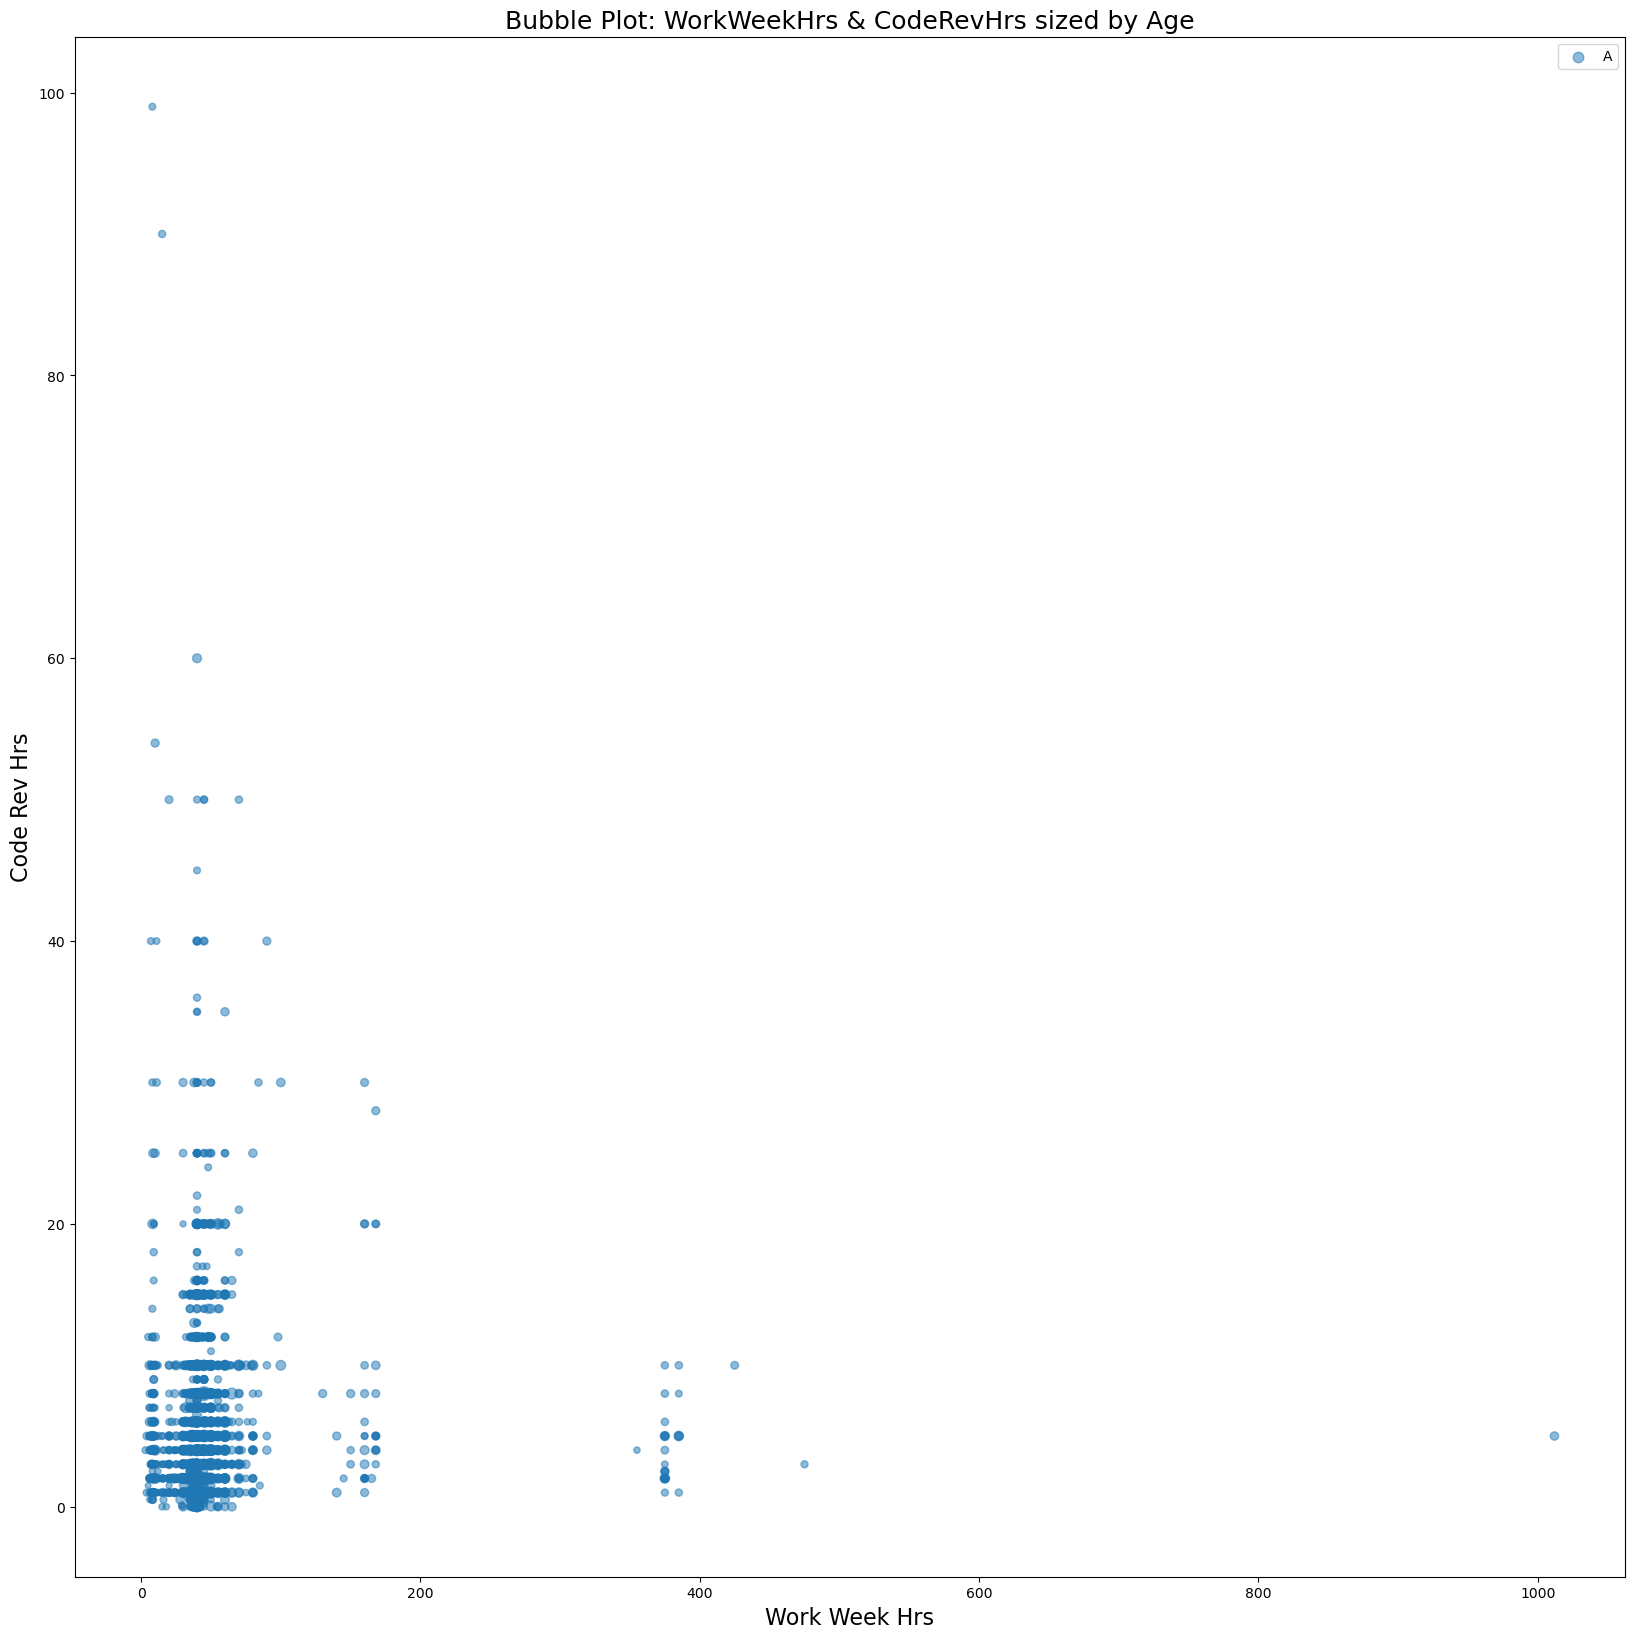

In [85]:
qryWorkWk = pd.read_sql_query("SELECT WorkWeekHrs FROM master", conn)
qryWorkCode = pd.read_sql_query("SELECT CodeRevHrs FROM master", conn)
qryAge = pd.read_sql_query("SELECT Age FROM master", conn)

plt.figure(figsize=(20, 20), edgecolor='blue')
plt.scatter(x = qryWorkWk, y = qryWorkCode, s = qryAge, alpha = 0.5)

plt.xlabel('Work Week Hrs', size=16)
plt.ylabel('Code Rev Hrs', size=16)
plt.legend('Age')
plt.title("Bubble Plot: WorkWeekHrs & CodeRevHrs sized by Age", size=18)

### Query to get ALL Values from DatabaseDesireNext Year for Analysis Writeup

In [96]:
QUERY = """ 
SELECT DatabaseDesireNextYear as futDB, count(DatabaseDesireNextYear) as cntDB from DatabaseDesireNextYear
group by futDB
order by cntDB DESC
"""

dfFutDBAll = pd.read_sql_query(QUERY, conn)
dfFutDBAll


,futDB,cntDB
0,PostgreSQL,4328
1,MongoDB,3649
2,Redis,3331
3,MySQL,3281
4,Elasticsearch,2856
5,Microsoft SQL Server,2706
6,SQLite,2437
7,Firebase,1650
8,MariaDB,1385
9,DynamoDB,1044


### Stacked Charts

In [97]:
# a stacked chart of median WorkWeekHrs and CodeRevHrs for the age group 30 to 35

QUERY = """
SELECT Age, WorkWeekHrs, CodeRevHrs FROM master
where Age between 30 and 35
order by Age DESC
"""

qryStkChrt = pd.read_sql_query(QUERY, conn)

In [98]:
if qryStkChrt['Age'].isnull().sum() > 0:
    meanAge = qryStkChrt['Age'].mean()
    qryStkChrt['Age'] = qryStkChrt['Age'].fillna(meanAge)
    
if qryStkChrt['WorkWeekHrs'].isnull().sum() > 0:
    meanWork = qryStkChrt['WorkWeekHrs'].mean()
    qryStkChrt['WorkWeekHrs'] = qryStkChrt['WorkWeekHrs'].fillna(meanWork)

if qryStkChrt['CodeRevHrs'].isnull().sum() > 0:
    meanCode = qryStkChrt['CodeRevHrs'].mean()
    qryStkChrt['CodeRevHrs'] = qryStkChrt['CodeRevHrs'].fillna(meanCode)

"""
medCodekHrs = qrydf['CodeRevHrs'].median()
qrydf['CodeRevHrs'] = df['CodeRevHrs'].fillna(medCodeHrs)
"""

"\nmedCodekHrs = qrydf['CodeRevHrs'].median()\nqrydf['CodeRevHrs'] = df['CodeRevHrs'].fillna(medCodeHrs)\n"

In [99]:
qryStkChrt2 = qryStkChrt[['WorkWeekHrs', 'CodeRevHrs', 'Age']]
qryStkChrt3 = qryStkChrt2.groupby(['Age'], as_index=False).median()
qryStkChrt3

,Age,WorkWeekHrs,CodeRevHrs
0,30.0,40.0,4.784443
1,31.0,40.0,4.784443
2,32.0,40.0,4.784443
3,33.0,40.0,4.000000
4,34.0,40.0,4.784443
5,35.0,40.0,4.784443


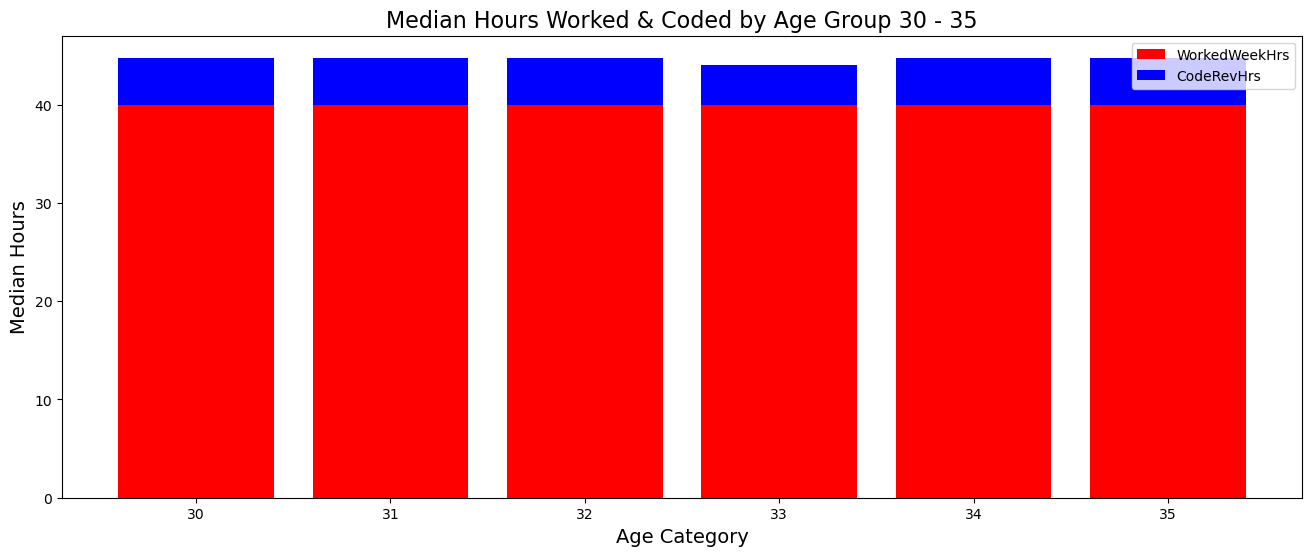

In [100]:
x = qryStkChrt3['Age']     #['A', 'B', 'C', 'D']
y1 = qryStkChrt3['WorkWeekHrs']     #np.array([10, 20, 10, 30])
y2 = qryStkChrt3['CodeRevHrs']     #np.array([20, 25, 15, 25])
  

plt.figure(figsize=(16, 6))

# plot bars in stack manner
plt.bar(x, y1, color='r')
plt.bar(x, y2, bottom=y1, color='b')

plt.xlabel("Age Category", size=14)
plt.ylabel("Median Hours", size=14)
plt.legend(["WorkedWeekHrs", "CodeRevHrs"])
plt.title("Median Hours Worked & Coded by Age Group 30 - 35", size=16)
plt.show()

### Analyzing WorkWeekHrs & CodeRevHrs by Age for All Ages

In [101]:
QUERY = """
SELECT Age, WorkWeekHrs, CodeRevHrs FROM master
order by Age DESC
"""

qryStkChrt = pd.read_sql_query(QUERY, conn)
qryStkChrt

,Age,WorkWeekHrs,CodeRevHrs
0,99.0,45.0,8.0
1,72.0,20.0,NaN
2,71.0,37.0,3.0
3,71.0,50.0,3.0
4,69.0,36.0,5.0
...,...,...,...
11393,NaN,50.0,5.0
11394,NaN,40.0,NaN
11395,NaN,65.0,7.0
11396,NaN,35.0,4.0


In [102]:
if qryStkChrt['Age'].isnull().sum() > 0:
    meanAge = qryStkChrt['Age'].mean()
    qryStkChrt['Age'] = qryStkChrt['Age'].fillna(meanAge)
    
if qryStkChrt['WorkWeekHrs'].isnull().sum() > 0:
    meanWork = qryStkChrt['WorkWeekHrs'].mean()
    qryStkChrt['WorkWeekHrs'] = qryStkChrt['WorkWeekHrs'].fillna(meanWork)

if qryStkChrt['CodeRevHrs'].isnull().sum() > 0:
    meanCode = qryStkChrt['CodeRevHrs'].mean()
    qryStkChrt['CodeRevHrs'] = qryStkChrt['CodeRevHrs'].fillna(meanCode)

"""
medCodekHrs = qrydf['CodeRevHrs'].median()
qrydf['CodeRevHrs'] = df['CodeRevHrs'].fillna(medCodeHrs)
"""

"\nmedCodekHrs = qrydf['CodeRevHrs'].median()\nqrydf['CodeRevHrs'] = df['CodeRevHrs'].fillna(medCodeHrs)\n"

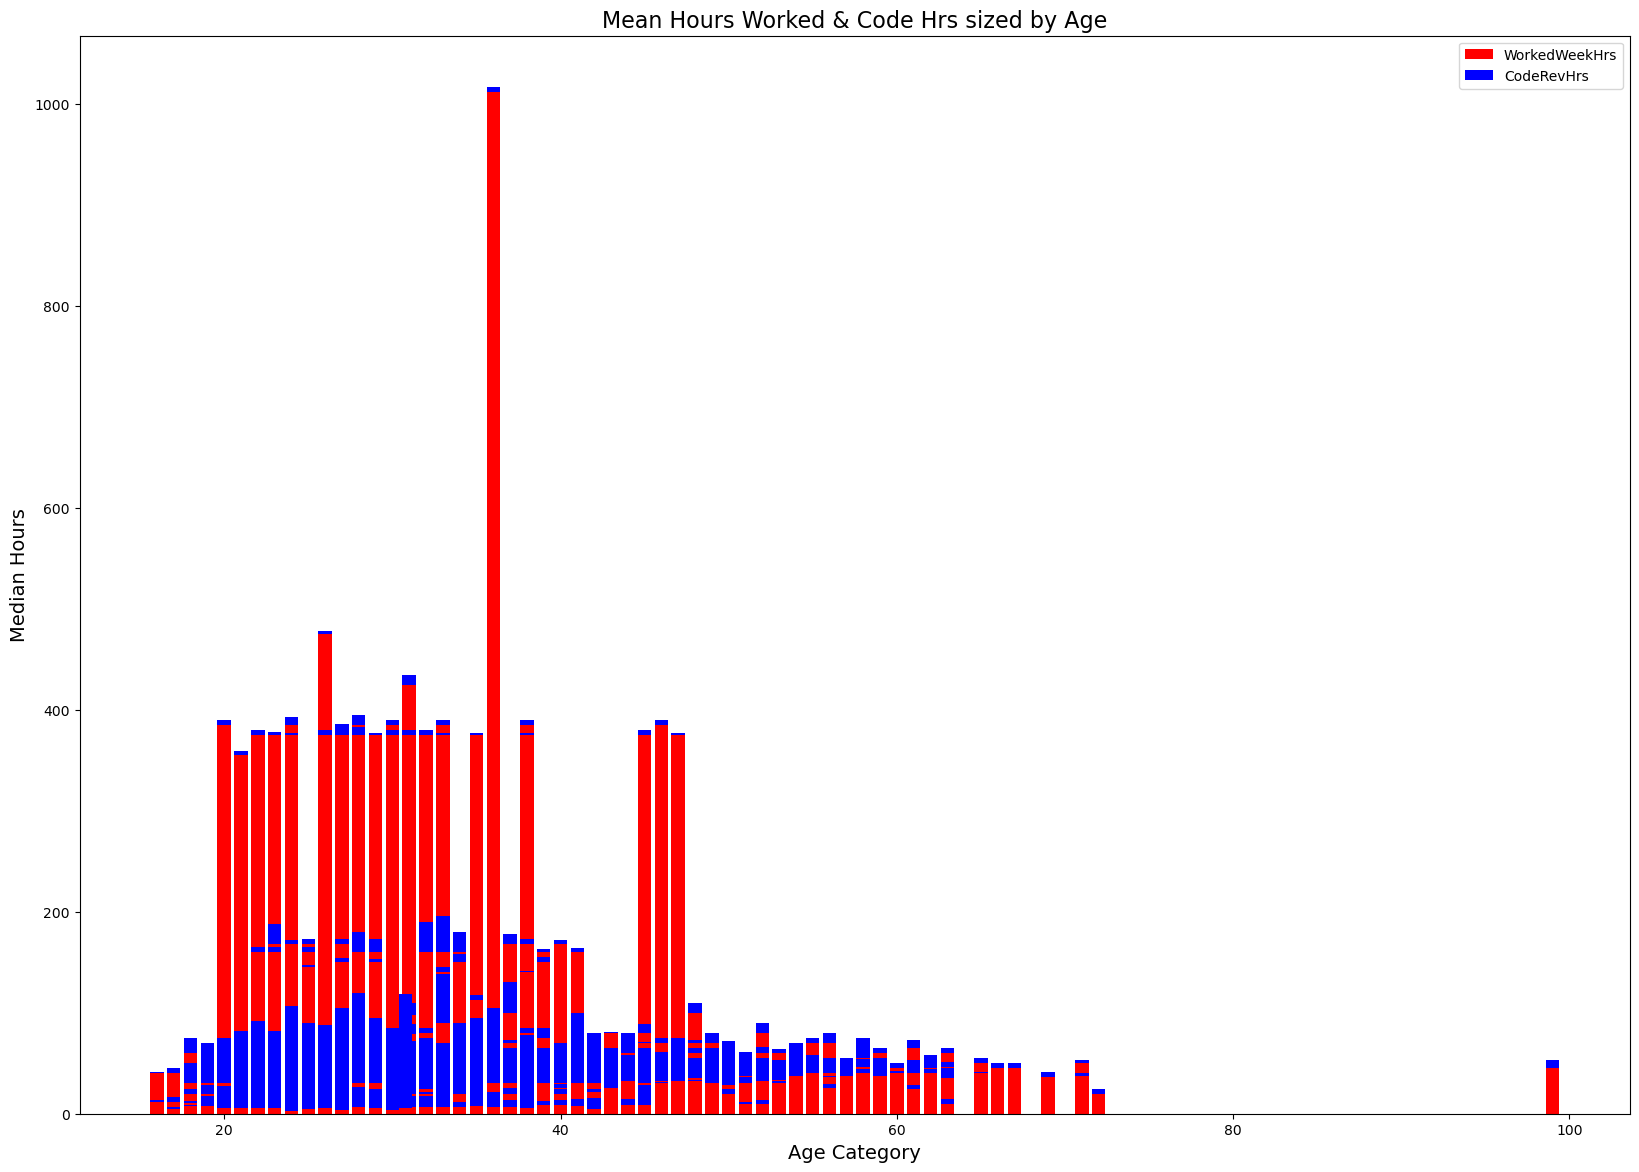

In [103]:
x = qryStkChrt['Age']     #['A', 'B', 'C', 'D']
y1 = qryStkChrt['WorkWeekHrs']     #np.array([10, 20, 10, 30])
y2 = qryStkChrt['CodeRevHrs']     #np.array([20, 25, 15, 25])
  

plt.figure(figsize=(20, 14))

# plot bars in stack manner
plt.bar(x, y1, color='r')
plt.bar(x, y2, bottom=y1, color='b')

plt.xlabel("Age Category", size=14)
plt.ylabel("Median Hours", size=14)
plt.legend(["WorkedWeekHrs", "CodeRevHrs"])
plt.title("Mean Hours Worked & Code Hrs sized by Age", size=16)
plt.show()

### Line Chart

In [104]:
QUERY = """
Select Age, ConvertedComp from master
where Age between 45 and 60
order by Age
"""

qryLnChrt = pd.read_sql_query(QUERY, conn)
qryLnChrt

,Age,ConvertedComp
0,45.0,72522.0
1,45.0,54876.0
2,45.0,185000.0
3,45.0,165000.0
4,45.0,130000.0
...,...,...
594,59.0,72530.0
595,59.0,160000.0
596,59.0,2000000.0
597,60.0,150000.0


In [105]:
if qryLnChrt['ConvertedComp'].isnull().sum() > 0:
    meanConv = qryLnChrt['ConvertedComp'].mean()
    qryLnChrt['ConvertedComp'] = qryLnChrt['ConvertedComp'].fillna(meanConv)

if qryLnChrt['Age'].isnull().sum() > 0:
    meanAge = qryLnChrt['Age'].mean()
    qryLnChrt['Age'] = qryLnChrt['Age'].fillna(meanAge)

In [106]:
qrydf_LnChrt = qryLnChrt[['Age', 'ConvertedComp']]
qrydf_LnChrt2 = qrydf_LnChrt.groupby(['Age'], as_index=False).median()
qrydf_LnChrt2

,Age,ConvertedComp
0,45.0,94210.0
1,46.0,103500.0
2,47.0,93746.0
3,48.0,108250.0
4,49.0,89520.0
5,50.0,95000.0
6,51.0,108423.0
7,52.0,106044.0
8,53.0,107754.5
9,54.0,122000.0


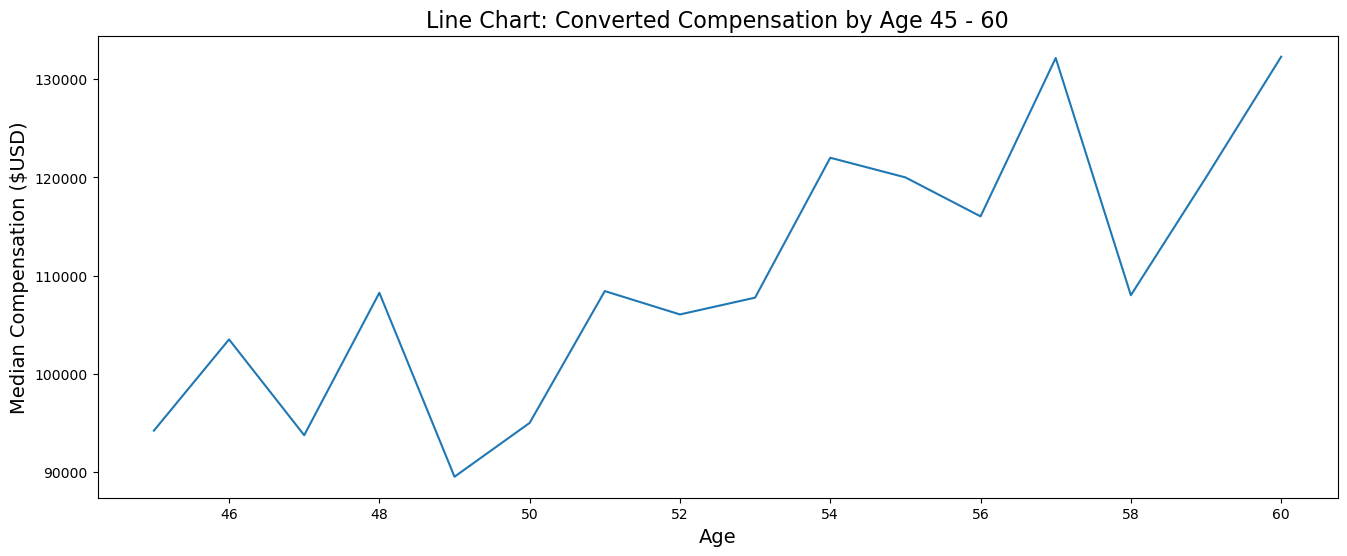

In [108]:
plt.figure(figsize=(16, 6))
plt.plot(qrydf_LnChrt2['Age'], qrydf_LnChrt2['ConvertedComp'])
plt.xlabel("Age", size=14)  # add X-axis label
plt.ylabel("Median Compensation ($USD)", size=14)  
plt.title("Line Chart: Converted Compensation by Age 45 - 60", size=16)  
plt.show()

### Bar Char

In [109]:
QUERY = """
SELECT MainBranch, count(MainBranch) as cntBranch from master
group by MainBranch
order by MainBranch
"""

qryBrnch = pd.read_sql_query(QUERY, conn)
qryBrnch

,MainBranch,cntBranch
0,I am a developer by profession,10618
1,"I am not primarily a developer, but I write co...",780


In [110]:
if qryBrnch['MainBranch'].isnull().sum() > 0:
    modeBrnch = qryBrnch['MainBranch'],mode().iloc[0]
    qryBrnch['MainBranch'] = qryBrnch['MainBranch'].fillna(modeBrnch)

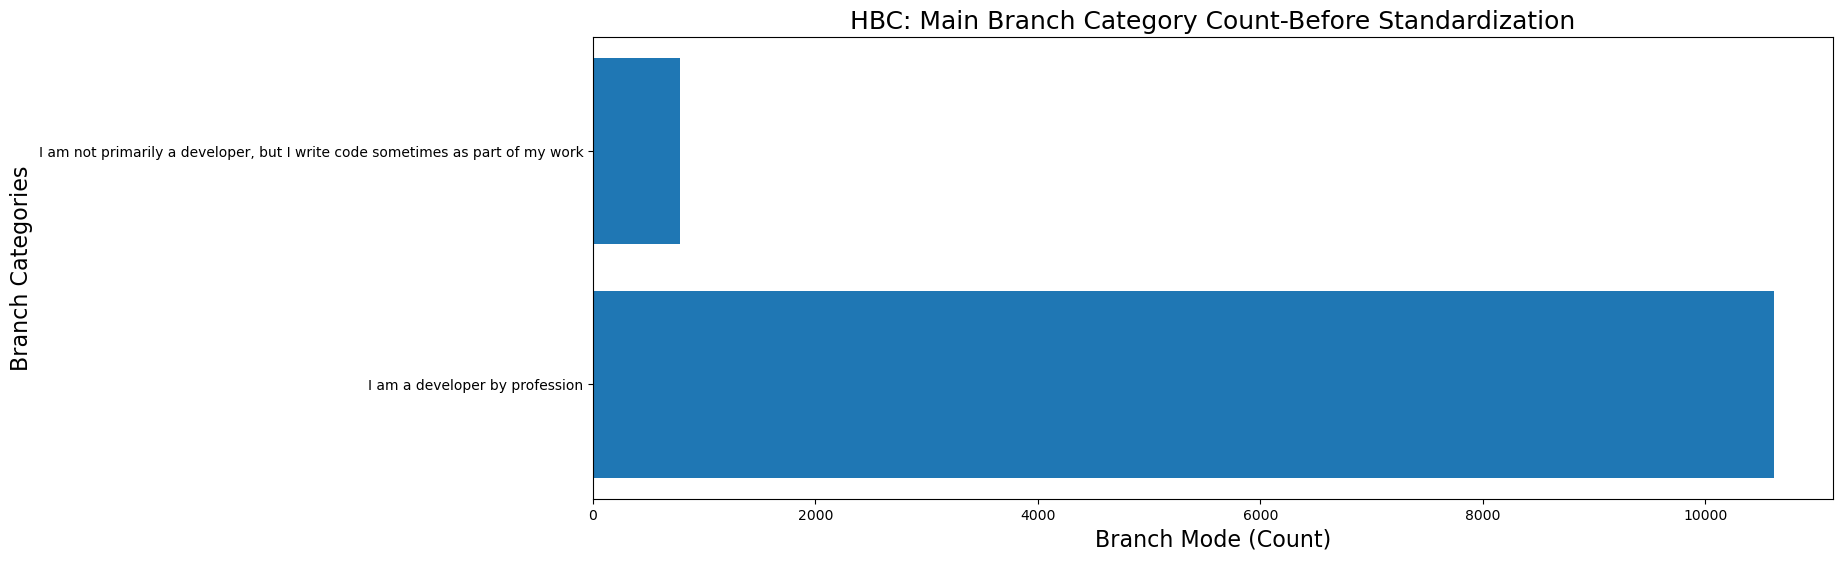

In [111]:
brnch = qryBrnch['MainBranch']
cnt = qryBrnch['cntBranch']

plt.figure(figsize=(16, 6))

plt.barh(brnch, cnt)   

plt.ylabel("Branch Categories", size=16)  # add X-axis label
plt.xlabel("Branch Mode (Count)", size=16)  # add Y-axis label
plt.title("HBC: Main Branch Category Count-Before Standardization", size=18)  # add title

plt.show()

In [112]:
qryBrnch['cntBranch'] = (qryBrnch['cntBranch'] - qryBrnch['cntBranch'].min()) / (qryBrnch['cntBranch'].max() - qryBrnch['cntBranch'].min())
qryBrnch

,MainBranch,cntBranch
0,I am a developer by profession,1.0
1,"I am not primarily a developer, but I write co...",0.0


In [113]:
qryBrnch.set_index("MainBranch", drop=False, inplace=True)

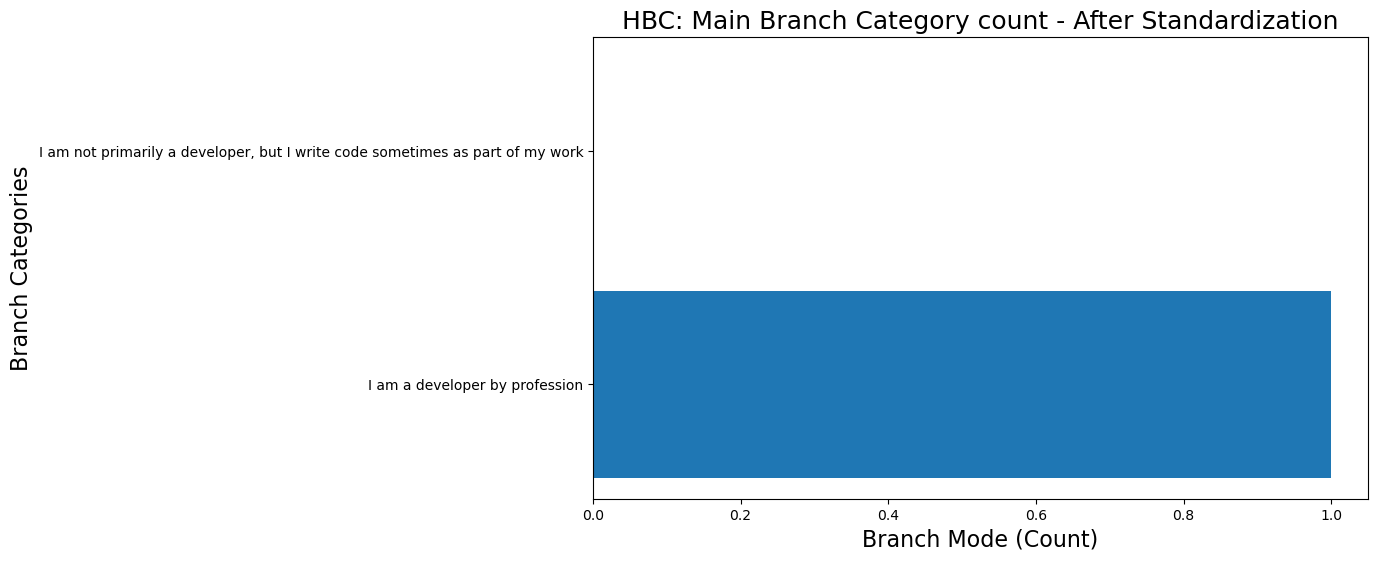

In [114]:
brnch = qryBrnch['MainBranch']
cnt = qryBrnch['cntBranch']

# Figure Size
plt.figure(figsize=(10, 6))

# Horizontal Bar Plot
plt.barh(brnch, cnt)   

plt.ylabel("Branch Categories", size=16)  # add X-axis label
plt.xlabel("Branch Mode (Count)", size=16)  # add Y-axis label
plt.title("HBC: Main Branch Category count - After Standardization", size=18)  # add title

# Show Plot
plt.show()


### BARCHART: TOP 5 CURRENT YEAR LANGUAGES

Text(0, 0.5, 'Language Worked WithFreqency')

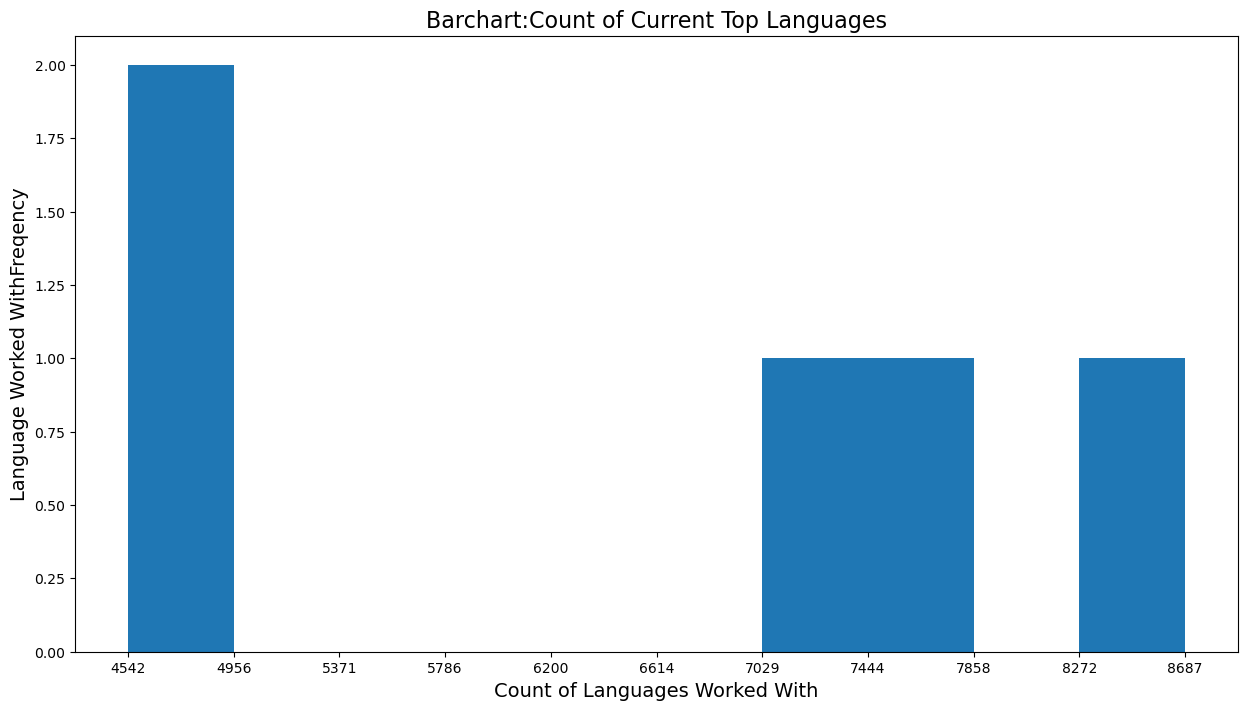

In [115]:
currLang = dfCurrLang['currLang']
cnt = dfCurrLang['cntLang']

count, bin_edges = np.histogram(dfCurrLang['cntLang'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfCurrLang["cntLang"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart:Count of Current Top Languages", size=16)
plt.xlabel("Count of Languages Worked With", size=14)
plt.ylabel("Language Worked WithFreqency", size=14)

Text(0, 0.5, 'Language Worked WithFreqency')

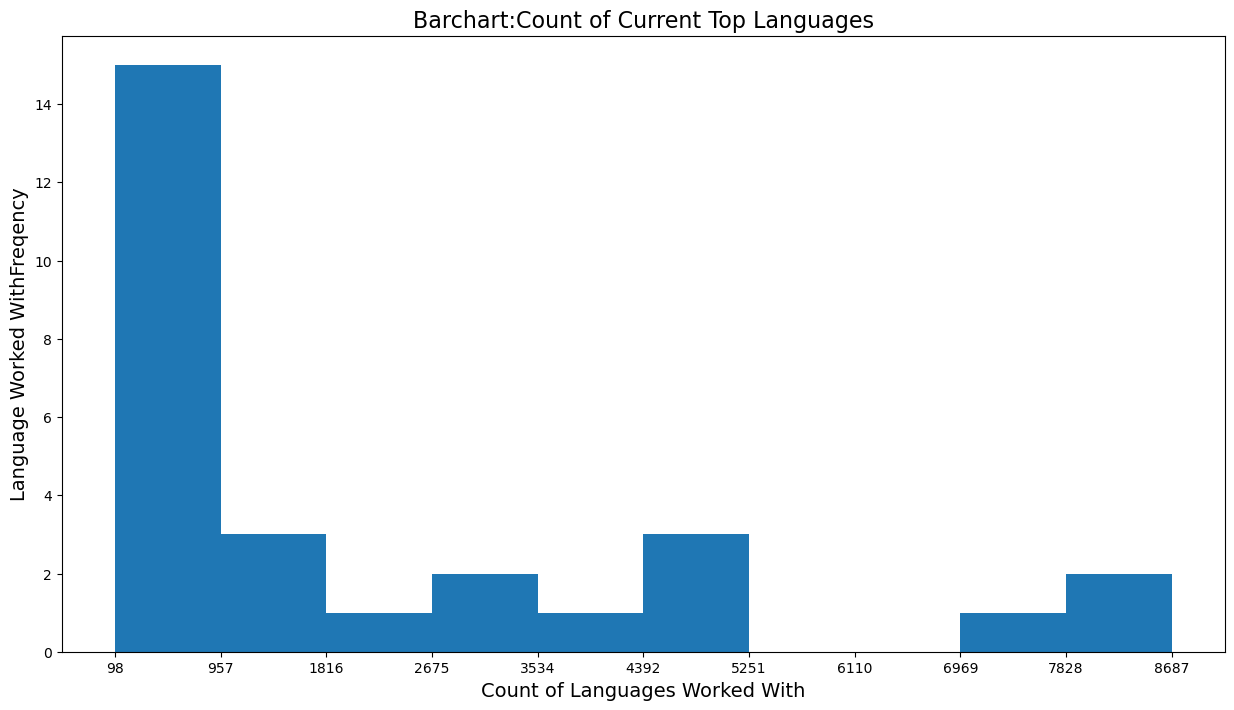

In [116]:
currLang = dfCurrLangAll['currLang']
cnt = dfCurrLangAll['cntLang']

count, bin_edges = np.histogram(dfCurrLangAll['cntLang'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfCurrLangAll["cntLang"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart:Count of Current Top Languages", size=16)
plt.xlabel("Count of Languages Worked With", size=14)
plt.ylabel("Language Worked WithFreqency", size=14)

### BARCHART: TOP 5 FUTURE (Next Year) LANGUAGE

Text(0, 0.5, 'Future Language Freqency')

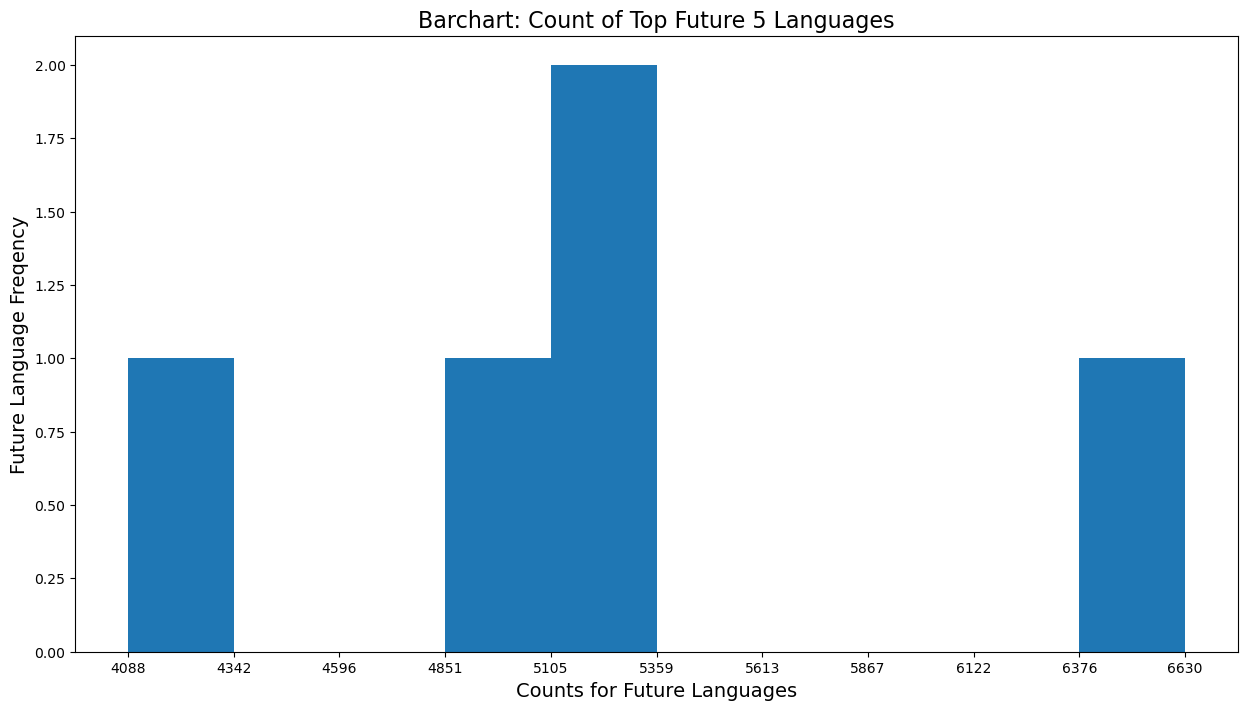

In [117]:
count, bin_edges = np.histogram(dfFutLang['cntLang'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfFutLang["cntLang"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Count of Top Future 5 Languages", size=16)
plt.xlabel("Counts for Future Languages", size=14)
plt.ylabel("Future Language Freqency", size=14)

Text(0, 0.5, 'Future Language Freqency')

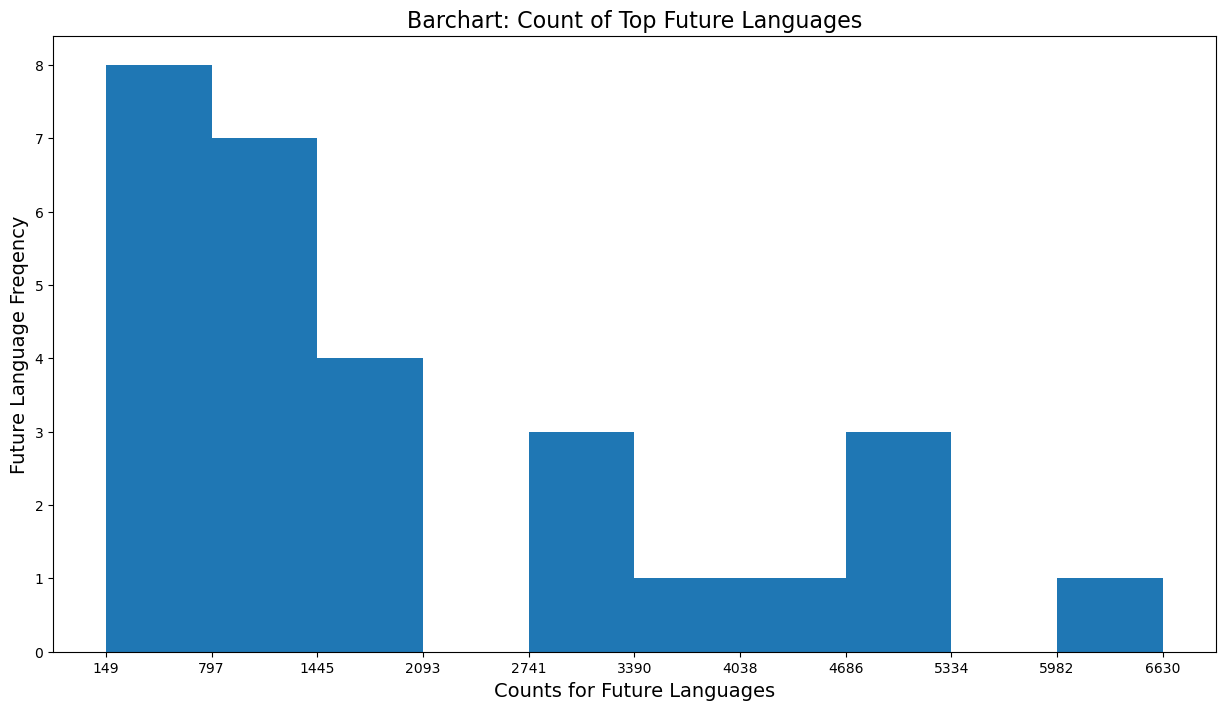

In [118]:
count, bin_edges = np.histogram(dfFutLangAll['cntLang'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfFutLangAll["cntLang"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Count of Top Future Languages", size=16)
plt.xlabel("Counts for Future Languages", size=14)
plt.ylabel("Future Language Freqency", size=14)

### BARCHART: TOP 5 Current DATABASES

Text(0, 0.5, 'Database Count Freqency')

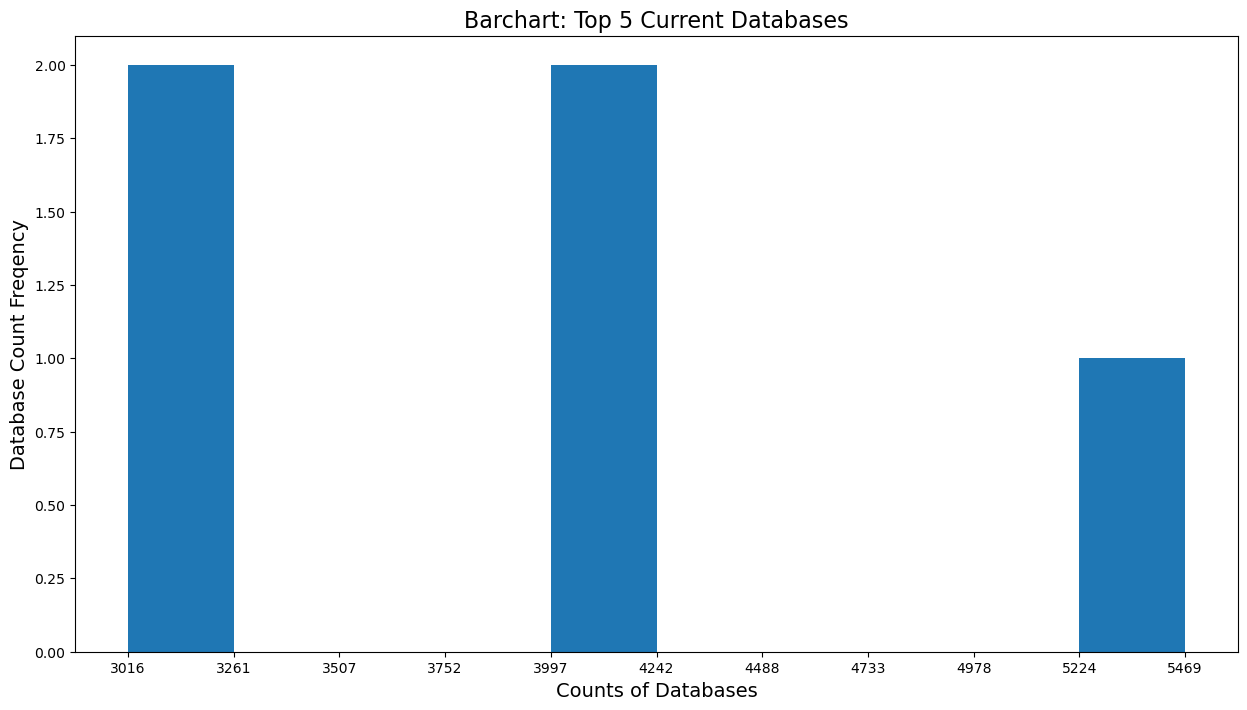

In [119]:
count, bin_edges = np.histogram(dfCurrDB['cntDB'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfCurrDB["cntDB"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Top 5 Current Databases", size=16)
plt.xlabel("Counts of Databases", size=14)
plt.ylabel("Database Count Freqency", size=14)


Text(0, 0.5, 'Database Count Freqency')

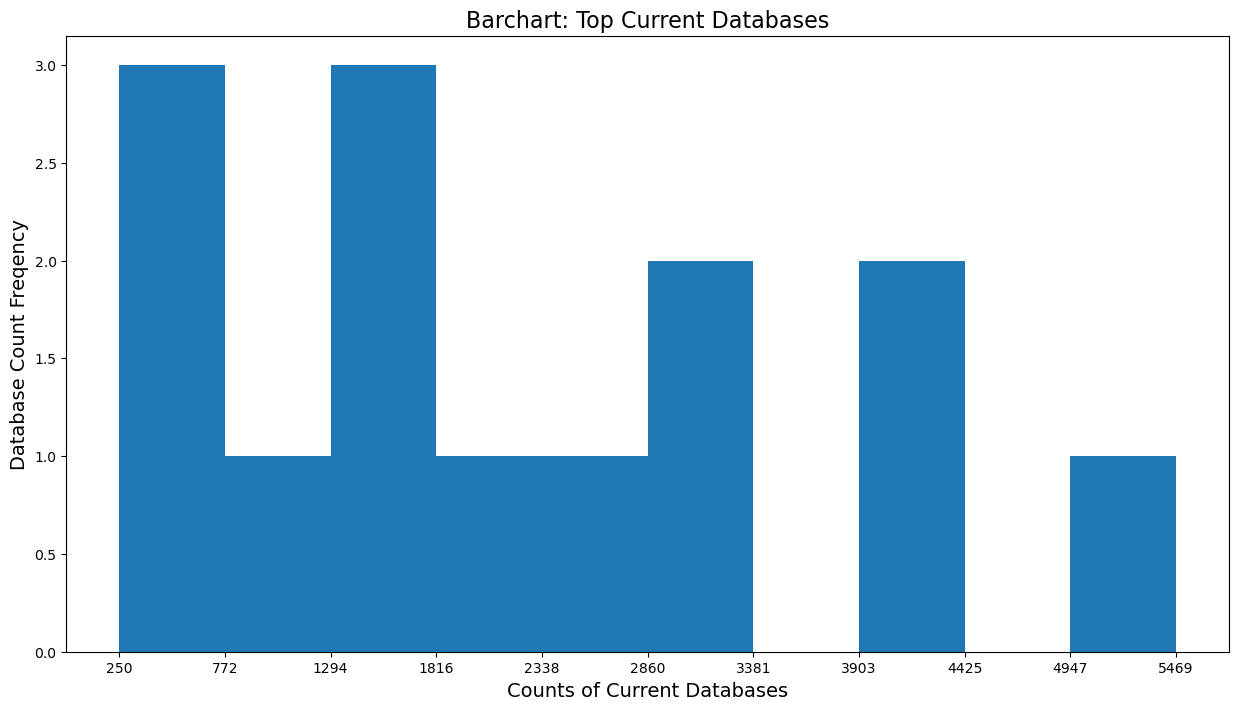

In [120]:
count, bin_edges = np.histogram(dfCurrDBAll['cntDB'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfCurrDBAll["cntDB"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Top Current Databases", size=16)
plt.xlabel("Counts of Current Databases", size=14)
plt.ylabel("Database Count Freqency", size=14)

### BARCHART: TOP 5 Future DATABASES

Text(0, 0.5, 'Count Future Database Freqency')

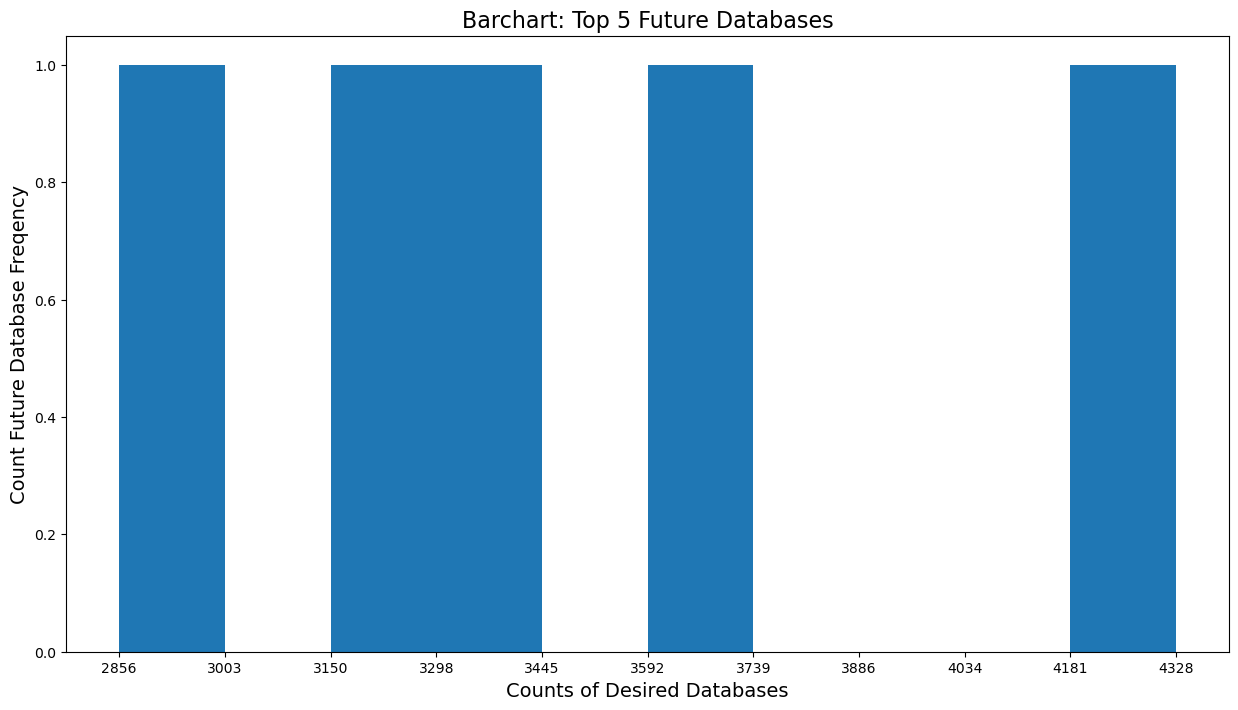

In [121]:
count, bin_edges = np.histogram(dfFutDB['cntDB'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfFutDB["cntDB"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Top 5 Future Databases", size=16)
plt.xlabel("Counts of Desired Databases", size=14)
plt.ylabel("Count Future Database Freqency", size=14)

Text(0, 0.5, 'Count Future Database Freqency')

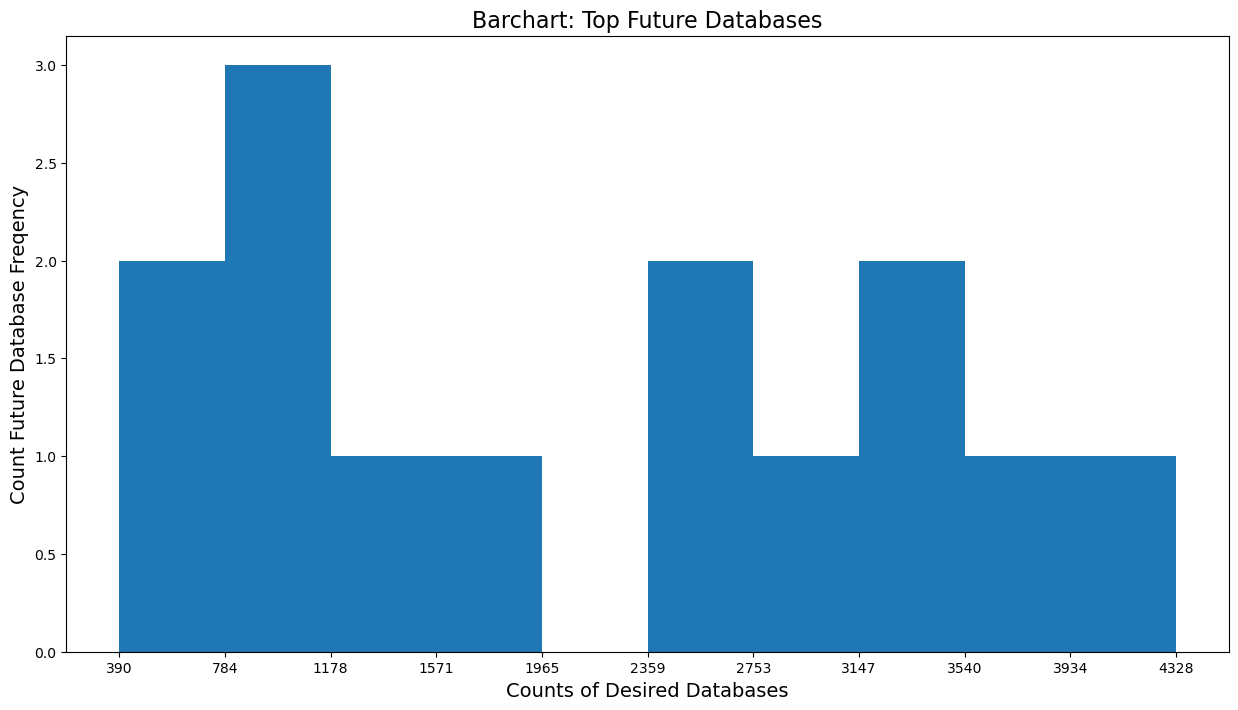

In [122]:
count, bin_edges = np.histogram(dfFutDBAll['cntDB'].dropna())
plt.figure(figsize=(15, 8), edgecolor='blue')
dfFutDBAll["cntDB"].plot(kind = 'hist', xticks=bin_edges)

#plt.figure(figsize=(15, 8), edgecolor='blue')
plt.title("Barchart: Top Future Databases", size=16)
plt.xlabel("Counts of Desired Databases", size=14)
plt.ylabel("Count Future Database Freqency", size=14)

In [123]:
conn.close()